# BARPA CDD period comparison with split tracks

This notebook keeps the original `plot_ccam_cdd_periods.ipynb` untouched and repeats the workflow using **split sub-tracks** whenever the time gap within a track exceeds a threshold.

Default rule:
- if `Time.diff() > 24 hours`, start a new sub-track

All maps, longevity summaries, and audit figures below use the split-track version.

In [3]:
%pip install numpy
%pip install pandas
%pip install cartopy
%pip install matplotlib



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached cartopy-0.25.0.tar.gz (10.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pyshp-3.1.6-py3-none-any.whl.metadata (79 kB)
Using cached pyshp-3.1.6-py3-none-any.whl (73 kB)
Failed to build cartopy
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for cartopy (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [1167 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\crs.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\geodesic.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\img_transform.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\util.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\vector_transform.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\_epsg.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\_version.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\__init__.py -> build\lib.win-amd64-cpython-314\cartopy
      creating build\lib.win-amd64-cpython-314\cartopy\feature
   

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from scipy import stats

ModuleNotFoundError: No module named 'cartopy'

In [ ]:
INPUT_CSV = Path(r"C:\Users\z3519988\OneDrive - UNSW\Files\study\project\csiro\ccam_cdd_all_ssp370.csv")
OUTPUT_DIR = Path(r"C:\Users\z3519988\OneDrive - UNSW\Files\study\project\csiro\ccam_cdd_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME_MAP = {
    "ERA5": "CCAM downscaled ERA5",
    "ACCESS-CM2": "CCAM downscaled ACCESS-CM2",
    "ACCESS-ESM1.5": "CCAM downscaled ACCESS-ESM1-5",
    "CMCC-ESM2": "CCAM downscaled CMCC-ESM2",
    "EC-Earth3": "CCAM downscaled EC-Earth3",
    "MPI-ESM1-2-HR": "CCAM downscaled MPI-ESM1-2-HR",
    "CESM2": "CCAM downscaled NCAR-CESM2",
    "NorESM2-MM": "CCAM downscaled NCC-NorESM2-MM",
}

PERIOD_PRESETS = {
    "historical_1981_2010": (1981, 2010),
    "historical_1991_2020": (1991, 2020),
    "future_2021_2050": (2021, 2050),
    "future_2031_2060": (2031, 2060),
    "future_2051_2080": (2051, 2080),
    "future_2071_2100": (2071, 2100),
    "future_2081_2100": (2081, 2100),
}

DEFAULT_MODELS = ["ACCESS-CM2"]
DEFAULT_PERIOD_CHOICES = ["historical_1991_2020", "future_2031_2060", "future_2071_2100"]
DEFAULT_CUSTOM_PERIODS = [None] * len(DEFAULT_PERIOD_CHOICES)

GAP_THRESHOLD_HOURS = 24

LONGEVITY_THRESHOLD_DAYS = 20
MAX_TRACKS_TO_PLOT = 6
TAIL_POINTS = 5
WEAK_TAIL_WSPD_THRESHOLD = 17.0
SUSPICIOUS_TRANSLATION_SPEED_KMH = 80.0

LON_RANGE = (100, 180)
LAT_RANGE = (-60, 0)
LON_BINS = np.linspace(LON_RANGE[0], LON_RANGE[1], 51)
LAT_BINS = np.linspace(LAT_RANGE[0], LAT_RANGE[1], 21)
DENSITY_LEVELS = [0, 1, 2, 5, 10, 20, 40, 80, 120, 160]



In [ ]:
raw_df = pd.read_csv(INPUT_CSV)
raw_df["Time"] = pd.to_datetime(raw_df["Time"], utc=True)
raw_df["BaseTrackKey"] = raw_df["Model"].astype(str) + "_" + raw_df["Season"].astype(str) + "_" + raw_df["TrackID"].astype(str)

print(f"Rows: {len(raw_df):,}")
print("Models in CSV:", sorted(raw_df["Model"].unique().tolist()))
raw_df.head()

Rows: 404,644
Models in CSV: ['ACCESS-CM2', 'ACCESS-ESM1.5', 'CESM2', 'CMCC-ESM2', 'EC-Earth3', 'ERA5', 'MPI-ESM1-2-HR', 'NorESM2-MM']


,Model,Tracker,TrackID,Season,Time,Year,Month,Day,Hour,Lon,Lat,Wspd,Pres,GWL1.2,GWL1.5,GWL2,GWL3,BaseTrackKey
0,ERA5,CDD,32,1981,1980-12-17 18:00:00+00:00,1980,12,17,1800,121.1,-14.0,15.2,994.2,False,False,False,False,ERA5_1981_32
1,ERA5,CDD,32,1981,1980-12-18 00:00:00+00:00,1980,12,18,0,120.8,-14.0,13.6,994.1,False,False,False,False,ERA5_1981_32
2,ERA5,CDD,32,1981,1980-12-18 06:00:00+00:00,1980,12,18,600,120.2,-13.9,14.7,991.8,False,False,False,False,ERA5_1981_32
3,ERA5,CDD,32,1981,1980-12-18 12:00:00+00:00,1980,12,18,1200,119.9,-13.6,15.4,991.2,False,False,False,False,ERA5_1981_32
4,ERA5,CDD,32,1981,1980-12-18 18:00:00+00:00,1980,12,18,1800,120.0,-13.6,16.4,989.8,False,False,False,False,ERA5_1981_32


In [ ]:
def split_tracks_by_gap(df, gap_threshold_hours=24):
    pieces = []
    for _, group in df.groupby(["Model", "Season", "TrackID"], sort=False):
        group = group.sort_values("Time").copy()
        gap_hours = group["Time"].diff().dt.total_seconds().div(3600)
        segment_id = (gap_hours.fillna(0) > gap_threshold_hours).cumsum() + 1
        group["SegmentID"] = segment_id.astype(int)
        group["TrackKey"] = group["BaseTrackKey"] + "_seg" + group["SegmentID"].astype(str)
        pieces.append(group)
    return pd.concat(pieces, ignore_index=True)


df = split_tracks_by_gap(raw_df, GAP_THRESHOLD_HOURS)
print("Split rows:", len(df))
print("Original track count:", raw_df["BaseTrackKey"].nunique())
print("Split track count:", df["TrackKey"].nunique())
df[["Model", "Season", "TrackID", "SegmentID", "TrackKey", "Time"]].head(12)

Split rows: 404644
Original track count: 15395
Split track count: 16588


,Model,Season,TrackID,SegmentID,TrackKey,Time
0,ERA5,1981,32,1,ERA5_1981_32_seg1,1980-12-17 18:00:00+00:00
1,ERA5,1981,32,1,ERA5_1981_32_seg1,1980-12-18 00:00:00+00:00
2,ERA5,1981,32,1,ERA5_1981_32_seg1,1980-12-18 06:00:00+00:00
3,ERA5,1981,32,1,ERA5_1981_32_seg1,1980-12-18 12:00:00+00:00
4,ERA5,1981,32,1,ERA5_1981_32_seg1,1980-12-18 18:00:00+00:00
5,ERA5,1981,32,1,ERA5_1981_32_seg1,1980-12-19 00:00:00+00:00
6,ERA5,1981,32,1,ERA5_1981_32_seg1,1980-12-19 06:00:00+00:00
7,ERA5,1981,32,1,ERA5_1981_32_seg1,1980-12-19 12:00:00+00:00
8,ERA5,1981,32,1,ERA5_1981_32_seg1,1980-12-19 18:00:00+00:00
9,ERA5,1981,32,1,ERA5_1981_32_seg1,1980-12-20 00:00:00+00:00


In [ ]:
def setup_map(ax, title):
    ax.set_extent([LON_RANGE[0], LON_RANGE[1], LAT_RANGE[0], LAT_RANGE[1]], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#f5f2e8", zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#dfeaf4", zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(title)


def resolve_period(period_choice, custom_period=None):
    return custom_period if custom_period is not None else PERIOD_PRESETS[period_choice]


def filter_period(df, model_name, season_start, season_end):
    return df[(df["Model"] == model_name) & (df["Season"].between(season_start, season_end))].copy()


def build_density(period_df):
    density, _, _ = np.histogram2d(
        period_df["Lat"],
        period_df["Lon"],
        bins=[LAT_BINS, LON_BINS],
        range=[[LAT_RANGE[0], LAT_RANGE[1]], [LON_RANGE[0], LON_RANGE[1]]],
    )
    return density


def build_density_samples_by_season(period_df):
    sample_grids = []
    for _, season_df in period_df.groupby("Season"):
        sample_grids.append(build_density(season_df))
    if not sample_grids:
        return np.empty((0, len(LAT_BINS) - 1, len(LON_BINS) - 1))
    return np.stack(sample_grids, axis=0)


def compute_density_welch_p_grid(period_df_1, period_df_2, min_samples=2):
    samples_1 = build_density_samples_by_season(period_df_1)
    samples_2 = build_density_samples_by_season(period_df_2)
    p_grid = np.full((len(LAT_BINS) - 1, len(LON_BINS) - 1), np.nan)
    if samples_1.shape[0] < min_samples or samples_2.shape[0] < min_samples:
        return p_grid
    for lat_i in range(p_grid.shape[0]):
        for lon_i in range(p_grid.shape[1]):
            a = samples_1[:, lat_i, lon_i]
            b = samples_2[:, lat_i, lon_i]
            result = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
            if np.isfinite(result.pvalue):
                p_grid[lat_i, lon_i] = result.pvalue
    return p_grid


def summarize_period(period_df, label, period_name):
    if period_df.empty:
        return {"label": label, "period": period_name, "rows": 0, "tracks": 0, "seasons": 0}
    return {
        "label": label,
        "period": period_name,
        "rows": int(len(period_df)),
        "tracks": int(period_df["TrackKey"].nunique()),
        "seasons": int(period_df["Season"].nunique()),
        "start_time": period_df["Time"].min().strftime("%Y-%m-%d"),
        "end_time": period_df["Time"].max().strftime("%Y-%m-%d"),
        "mean_wspd": float(period_df["Wspd"].mean()),
        "max_wspd": float(period_df["Wspd"].max()),
        "mean_pres": float(period_df["Pres"].mean()),
        "min_pres": float(period_df["Pres"].min()),
    }


def plot_track_map(ax, period_df, title):
    setup_map(ax, title)
    for _, track in period_df.groupby("TrackKey", sort=False):
        ax.plot(track["Lon"], track["Lat"], color="firebrick", linewidth=0.7, alpha=0.55, transform=ccrs.PlateCarree())
        first = track.iloc[0]
        ax.plot(first["Lon"], first["Lat"], "o", color="navy", markersize=1.8, alpha=0.8, transform=ccrs.PlateCarree())


def plot_density_map(ax, period_df, title):
    setup_map(ax, title)
    density = build_density(period_df)
    cmap = plt.get_cmap("hot_r")
    norm = BoundaryNorm(DENSITY_LEVELS, ncolors=cmap.N, clip=True)
    mesh = ax.pcolormesh(LON_BINS, LAT_BINS, density, cmap=cmap, norm=norm, shading="auto", transform=ccrs.PlateCarree())
    return mesh, density


def plot_difference_map(ax, density_1, density_2, p_grid, title, alpha=0.05):
    setup_map(ax, title)
    diff = density_2 - density_1
    vmax = np.nanmax(np.abs(diff))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1
    mesh = ax.pcolormesh(LON_BINS, LAT_BINS, diff, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto", transform=ccrs.PlateCarree())
    if p_grid is not None:
        sig_mask = np.isfinite(p_grid) & (p_grid < alpha)
        if np.any(sig_mask):
            lon_centers = (LON_BINS[:-1] + LON_BINS[1:]) / 2
            lat_centers = (LAT_BINS[:-1] + LAT_BINS[1:]) / 2
            yy, xx = np.where(sig_mask)
            ax.scatter(lon_centers[xx], lat_centers[yy], s=7, c="black", marker="o", linewidths=0, alpha=0.7, transform=ccrs.PlateCarree())
    return mesh, diff


def build_track_longevity(period_df, label, period_name):
    records = []
    if period_df.empty:
        return pd.DataFrame(columns=["label", "period", "TrackKey", "Season", "TrackID", "SegmentID", "start_time", "end_time", "duration_hours", "duration_days", "n_points", "mean_wspd", "max_wspd", "mean_pres", "min_pres"])
    for track_key, track_df in period_df.groupby("TrackKey", sort=False):
        track_df = track_df.sort_values("Time")
        start_time = track_df["Time"].min()
        end_time = track_df["Time"].max()
        duration_hours = (end_time - start_time).total_seconds() / 3600.0
        records.append({
            "label": label,
            "period": period_name,
            "TrackKey": track_key,
            "Season": int(track_df["Season"].iloc[0]),
            "TrackID": track_df["TrackID"].iloc[0],
            "SegmentID": int(track_df["SegmentID"].iloc[0]),
            "start_time": start_time.strftime("%Y-%m-%d %H:%M:%S"),
            "end_time": end_time.strftime("%Y-%m-%d %H:%M:%S"),
            "duration_hours": float(duration_hours),
            "duration_days": float(duration_hours / 24.0),
            "n_points": int(len(track_df)),
            "mean_wspd": float(track_df["Wspd"].mean()),
            "max_wspd": float(track_df["Wspd"].max()),
            "mean_pres": float(track_df["Pres"].mean()),
            "min_pres": float(track_df["Pres"].min()),
        })
    return pd.DataFrame(records)


def summarize_longevity(longevity_df):
    if longevity_df.empty:
        return {"n_tracks": 0, "mean_days": np.nan, "median_days": np.nan, "p90_days": np.nan, "max_days": np.nan, "mean_points": np.nan, "long_lived_ge_5_days": 0, "long_lived_ge_7_days": 0}
    durations = longevity_df["duration_days"]
    return {
        "n_tracks": int(len(longevity_df)),
        "mean_days": float(durations.mean()),
        "median_days": float(durations.median()),
        "p90_days": float(durations.quantile(0.9)),
        "max_days": float(durations.max()),
        "mean_points": float(longevity_df["n_points"].mean()),
        "long_lived_ge_5_days": int((durations >= 5).sum()),
        "long_lived_ge_7_days": int((durations >= 7).sum()),
    }


def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2.0 * r * np.arcsin(np.sqrt(a))


def audit_track(track_df, label, period_name):
    track_df = track_df.sort_values("Time").copy()
    start_time = track_df["Time"].min()
    end_time = track_df["Time"].max()
    duration_hours = (end_time - start_time).total_seconds() / 3600.0
    duration_days = duration_hours / 24.0
    lat1 = track_df["Lat"].to_numpy()[:-1]
    lon1 = track_df["Lon"].to_numpy()[:-1]
    lat2 = track_df["Lat"].to_numpy()[1:]
    lon2 = track_df["Lon"].to_numpy()[1:]
    step_km = haversine_km(lat1, lon1, lat2, lon2) if len(track_df) > 1 else np.array([])
    time_values = track_df["Time"].to_numpy()
    dt_hours = np.diff(time_values).astype("timedelta64[s]").astype(float) / 3600.0 if len(track_df) > 1 else np.array([])
    step_speed = np.divide(step_km, dt_hours, out=np.full_like(step_km, np.nan, dtype=float), where=dt_hours > 0) if len(track_df) > 1 else np.array([])
    tail_df = track_df.tail(min(TAIL_POINTS, len(track_df)))
    tail_mean_wspd = float(tail_df["Wspd"].mean()) if not tail_df.empty else np.nan
    tail_min_pres = float(tail_df["Pres"].min()) if not tail_df.empty else np.nan
    warning_flags = []
    if np.isfinite(step_speed).any() and float(np.nanmax(step_speed)) > SUSPICIOUS_TRANSLATION_SPEED_KMH:
        warning_flags.append("suspicious_jump")
    if duration_days >= LONGEVITY_THRESHOLD_DAYS and tail_mean_wspd < WEAK_TAIL_WSPD_THRESHOLD:
        warning_flags.append("weak_long_lived_tail")
    if len(track_df) <= 4:
        warning_flags.append("very_few_points")
    return {
        "label": label,
        "period": period_name,
        "TrackKey": track_df["TrackKey"].iloc[0],
        "Season": int(track_df["Season"].iloc[0]),
        "TrackID": track_df["TrackID"].iloc[0],
        "SegmentID": int(track_df["SegmentID"].iloc[0]),
        "duration_days": float(duration_days),
        "n_points": int(len(track_df)),
        "start_time": start_time.strftime("%Y-%m-%d %H:%M:%S"),
        "end_time": end_time.strftime("%Y-%m-%d %H:%M:%S"),
        "max_step_km": float(np.nanmax(step_km)) if len(step_km) else np.nan,
        "max_translation_speed_kmh": float(np.nanmax(step_speed)) if len(step_speed) else np.nan,
        "tail_mean_wspd": tail_mean_wspd,
        "tail_min_pres": tail_min_pres,
        "mean_wspd": float(track_df["Wspd"].mean()),
        "max_wspd": float(track_df["Wspd"].max()),
        "mean_pres": float(track_df["Pres"].mean()),
        "min_pres": float(track_df["Pres"].min()),
        "warning_flags": ", ".join(warning_flags) if warning_flags else "none",
    }


def plot_audit_track_row(ax_map, ax_ts, track_df, meta):
    setup_map(ax_map, f"{meta['TrackKey']}\n{meta['duration_days']:.1f} days")
    ax_map.plot(track_df["Lon"], track_df["Lat"], color="firebrick", linewidth=1.1, transform=ccrs.PlateCarree())
    ax_map.plot(track_df["Lon"].iloc[0], track_df["Lat"].iloc[0], "o", color="navy", markersize=3, transform=ccrs.PlateCarree())
    ax_map.plot(track_df["Lon"].iloc[-1], track_df["Lat"].iloc[-1], "s", color="black", markersize=3, transform=ccrs.PlateCarree())
    ax_ts.plot(track_df["Time"], track_df["Wspd"], color="crimson", label="Wspd")
    ax_ts.set_ylabel("Wind speed")
    ax_ts.set_title(meta["warning_flags"])
    ax_ts.grid(True, linewidth=0.3, alpha=0.4)
    ax_ts2 = ax_ts.twinx()
    ax_ts2.plot(track_df["Time"], track_df["Pres"], color="navy", label="Pres")
    ax_ts2.set_ylabel("Pressure")
    lines1, labels1 = ax_ts.get_legend_handles_labels()
    lines2, labels2 = ax_ts2.get_legend_handles_labels()
    ax_ts.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=8)

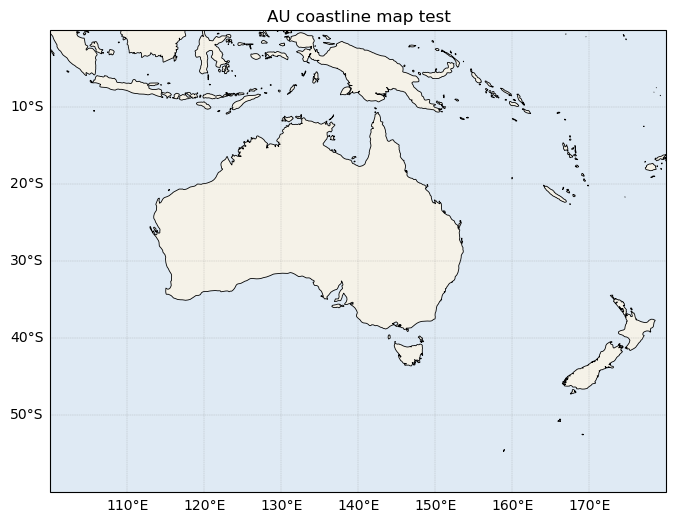

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
setup_map(ax, "AU coastline map test")
plt.show()

In [ ]:
available_periods = (
    df.groupby("Model")["Season"]
    .agg(min_season="min", max_season="max", n_seasons="nunique")
    .reset_index()
)
available_periods["label"] = available_periods["Model"].map(lambda x: MODEL_NAME_MAP.get(x, x))
available_periods = available_periods[["Model", "label", "min_season", "max_season", "n_seasons"]]
print("Gap threshold hours:", GAP_THRESHOLD_HOURS)
available_periods

Gap threshold hours: 24


,Model,label,min_season,max_season,n_seasons
0,ACCESS-CM2,CCAM downscaled ACCESS-CM2,1960,2101,142
1,ACCESS-ESM1.5,CCAM downscaled ACCESS-ESM1-5,1960,2101,142
2,CESM2,CCAM downscaled NCAR-CESM2,1960,2101,142
3,CMCC-ESM2,CCAM downscaled CMCC-ESM2,1960,2100,141
4,EC-Earth3,CCAM downscaled EC-Earth3,1960,2101,142
5,ERA5,CCAM downscaled ERA5,1981,2020,40
6,MPI-ESM1-2-HR,CCAM downscaled MPI-ESM1-2-HR,1960,2100,141
7,NorESM2-MM,CCAM downscaled NCC-NorESM2-MM,1960,2101,142


## Choose models and periods

In [ ]:
selected_models = DEFAULT_MODELS
selected_period_choices = DEFAULT_PERIOD_CHOICES
selected_custom_periods = DEFAULT_CUSTOM_PERIODS

if len(selected_custom_periods) < len(selected_period_choices):
    selected_custom_periods = selected_custom_periods + [None] * (len(selected_period_choices) - len(selected_custom_periods))

selected_periods = [
    resolve_period(period_choice, custom_period)
    for period_choice, custom_period in zip(selected_period_choices, selected_custom_periods)
]

comparison_specs = []
for model in selected_models:
    for period in selected_periods:
        comparison_specs.append({
            "model": model,
            "label": MODEL_NAME_MAP.get(model, model),
            "period": period,
        })

pd.DataFrame(comparison_specs)


,model,label,period
0,ACCESS-ESM1.5,CCAM downscaled ACCESS-ESM1-5,"(1991, 2020)"
1,ACCESS-ESM1.5,CCAM downscaled ACCESS-ESM1-5,"(2031, 2060)"
2,ACCESS-ESM1.5,CCAM downscaled ACCESS-ESM1-5,"(2071, 2100)"


In [ ]:
comparison_frames = []
summary_rows = []
validation_rows = []
model_bounds = df.groupby("Model")["Season"].agg(["min", "max"]).to_dict("index")

for spec in comparison_specs:
    start_season, end_season = spec["period"]
    model_min = int(model_bounds[spec["model"]]["min"])
    model_max = int(model_bounds[spec["model"]]["max"])
    clipped_start = max(start_season, model_min)
    clipped_end = min(end_season, model_max)
    valid = clipped_start <= clipped_end
    validation_rows.append({
        "model": spec["model"],
        "requested_period": f"{start_season}-{end_season}",
        "available_period": f"{model_min}-{model_max}",
        "used_period": f"{clipped_start}-{clipped_end}" if valid else "no overlap",
    })
    period_df = filter_period(df, spec["model"], clipped_start, clipped_end) if valid else df.iloc[0:0].copy()
    comparison_frames.append((spec, period_df, (clipped_start, clipped_end), valid))
    summary_rows.append(summarize_period(period_df, spec["label"], f"{clipped_start}-{clipped_end}" if valid else "no overlap"))

print("Selected periods after checking CSV availability:")
pd.DataFrame(validation_rows)

Selected periods after checking CSV availability:


,model,requested_period,available_period,used_period
0,ACCESS-ESM1.5,1991-2020,1960-2101,1991-2020
1,ACCESS-ESM1.5,2031-2060,1960-2101,2031-2060
2,ACCESS-ESM1.5,2071-2100,1960-2101,2071-2100


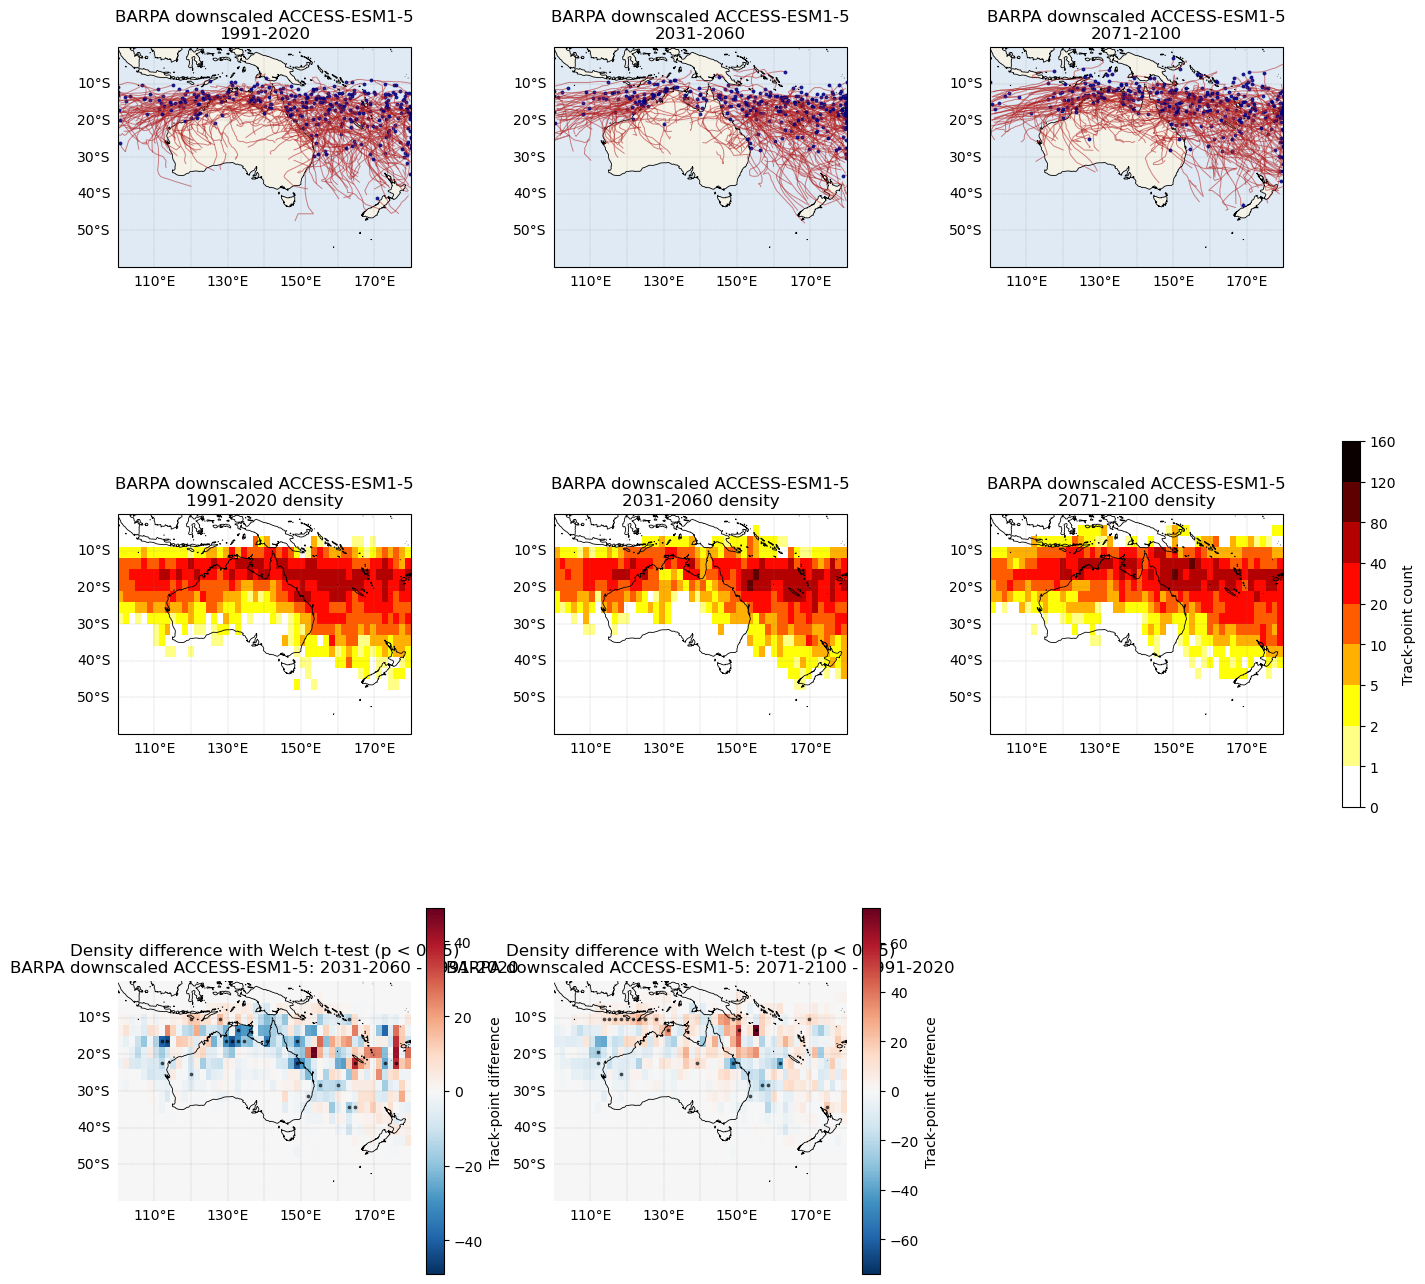

In [ ]:
subplot_kw = {"projection": ccrs.PlateCarree()}
ncols = len(comparison_frames)
fig, axes = plt.subplots(3, ncols, figsize=(4.5 * ncols, 14), constrained_layout=True, subplot_kw=subplot_kw)
if ncols == 1:
    axes = np.array(axes).reshape(3, 1)

density_arrays = []
density_mesh = None
period_dfs = []
for idx, (spec, period_df, used_period, valid) in enumerate(comparison_frames):
    start_season, end_season = used_period
    title = f"{spec['label']}\n{start_season}-{end_season}" if valid else f"{spec['label']}\nno overlap"
    plot_track_map(axes[0, idx], period_df, title)
    density_mesh, density_array = plot_density_map(axes[1, idx], period_df, f"{title} density")
    density_arrays.append(density_array)
    period_dfs.append(period_df)

if density_mesh is not None:
    fig.colorbar(density_mesh, ax=axes[1, :], shrink=0.8, label="Track-point count")

# Show two reference diffs for the first selected model: middle-first and last-first.
for idx in range(ncols):
    axes[2, idx].axis("off")

if len(selected_models) >= 1 and len(selected_periods) >= 2:
    ref_model = selected_models[0]
    ref_period_base = selected_periods[0]
    ref_diff_periods = selected_periods[1:3]
    for diff_panel_idx, ref_period_future in enumerate(ref_diff_periods[:ncols]):
        idx_base = next((i for i, spec in enumerate(comparison_specs) if spec['model'] == ref_model and spec['period'] == ref_period_base), None)
        idx_future = next((i for i, spec in enumerate(comparison_specs) if spec['model'] == ref_model and spec['period'] == ref_period_future), None)
        if idx_base is None or idx_future is None:
            continue
        if period_dfs[idx_base].empty or period_dfs[idx_future].empty:
            continue
        p_grid = compute_density_welch_p_grid(period_dfs[idx_base], period_dfs[idx_future])
        diff_title = f"Density difference with Welch t-test (p < 0.05)\n{MODEL_NAME_MAP.get(ref_model, ref_model)}: {ref_period_future[0]}-{ref_period_future[1]} - {ref_period_base[0]}-{ref_period_base[1]}"
        diff_mesh, diff_array = plot_difference_map(axes[2, diff_panel_idx], density_arrays[idx_base], density_arrays[idx_future], p_grid, diff_title)
        fig.colorbar(diff_mesh, ax=axes[2, diff_panel_idx], shrink=0.8, label="Track-point difference")

selected_name = "_".join([m.replace('.', '_') for m in selected_models]) + "_split_tracks_comparison"
fig.savefig(OUTPUT_DIR / f"{selected_name}.png", dpi=300)
plt.show()

if len(selected_periods) >= 2:
    ref_period_base = selected_periods[0]
    ref_diff_periods = selected_periods[1:]
    for model in selected_models:
        for ref_period_future in ref_diff_periods:
            idx_base = next((i for i, spec in enumerate(comparison_specs) if spec['model'] == model and spec['period'] == ref_period_base), None)
            idx_future = next((i for i, spec in enumerate(comparison_specs) if spec['model'] == model and spec['period'] == ref_period_future), None)
            if idx_base is None or idx_future is None:
                continue
            diff_df_base = period_dfs[idx_base]
            diff_df_future = period_dfs[idx_future]
            if diff_df_base.empty or diff_df_future.empty:
                continue
            p_grid = compute_density_welch_p_grid(diff_df_base, diff_df_future)
            fig_diff, ax_diff = plt.subplots(figsize=(9, 6), constrained_layout=True, subplot_kw={"projection": ccrs.PlateCarree()})
            diff_title = f"Density difference with Welch t-test (p < 0.05)\n{MODEL_NAME_MAP.get(model, model)}: {ref_period_future[0]}-{ref_period_future[1]} - {ref_period_base[0]}-{ref_period_base[1]}"
            diff_mesh, diff_array = plot_difference_map(ax_diff, density_arrays[idx_base], density_arrays[idx_future], p_grid, diff_title)
            fig_diff.colorbar(diff_mesh, ax=ax_diff, shrink=0.82, pad=0.03, label="Track-point difference")
            safe_model = model.replace('.', '_')
            fig_diff.savefig(OUTPUT_DIR / f"density_diff_split_tracks_{safe_model}_{ref_period_future[0]}_{ref_period_future[1]}_minus_{ref_period_base[0]}_{ref_period_base[1]}.png", dpi=300)
            plt.close(fig_diff)



In [ ]:
output_summary = pd.DataFrame(summary_rows)
output_summary.to_csv(OUTPUT_DIR / "ccam_cdd_split_tracks_comparison_summary.csv", index=False)
output_summary

,label,period,rows,tracks,seasons,start_time,end_time,mean_wspd,max_wspd,mean_pres,min_pres
0,CCAM downscaled ACCESS-ESM1-5,1991-2020,7784,323,30,1991-01-26,2020-05-26,20.698484,46.5,990.197122,941.4
1,CCAM downscaled ACCESS-ESM1-5,2031-2060,6856,274,30,2030-12-03,2060-04-12,21.601429,48.4,988.755120,935.8
2,CCAM downscaled ACCESS-ESM1-5,2071-2100,8030,322,30,2071-01-06,2100-04-11,22.112154,44.3,988.431557,927.6


## Track longevity comparison

In [ ]:
longevity_frames = []
longevity_summary_rows = []
for spec, period_df, used_period, valid in comparison_frames:
    start_season, end_season = used_period
    period_name = f"{start_season}-{end_season}" if valid else "no overlap"
    longevity_df = build_track_longevity(period_df, spec["label"], period_name)
    longevity_frames.append((spec, longevity_df, period_name))
    summary = summarize_longevity(longevity_df)
    summary.update({"label": spec["label"], "model": spec["model"], "period": period_name})
    longevity_summary_rows.append(summary)
longevity_summary_df = pd.DataFrame(longevity_summary_rows)
longevity_summary_df

,n_tracks,mean_days,median_days,p90_days,max_days,mean_points,long_lived_ge_5_days,long_lived_ge_7_days,label,model,period
0,323,6.035604,5.00,11.500,31.25,24.099071,166,111,CCAM downscaled ACCESS-ESM1-5,ACCESS-ESM1.5,1991-2020
1,274,6.212591,5.25,12.425,31.75,25.021898,151,98,CCAM downscaled ACCESS-ESM1-5,ACCESS-ESM1.5,2031-2060
2,322,6.256211,5.00,13.500,24.25,24.937888,167,111,CCAM downscaled ACCESS-ESM1-5,ACCESS-ESM1.5,2071-2100


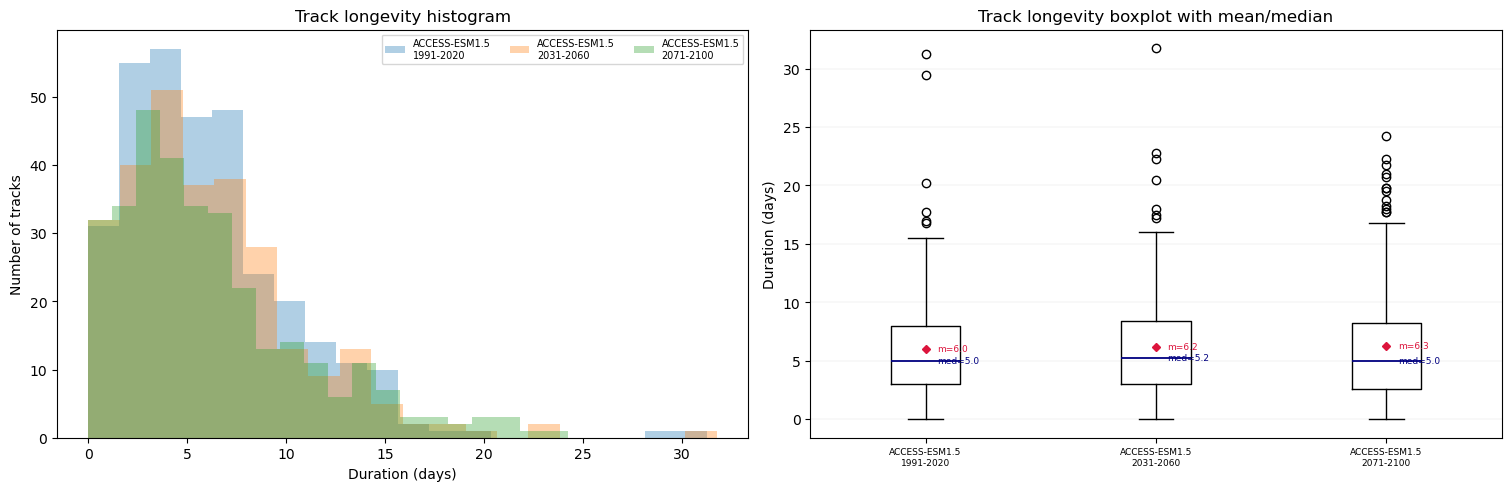

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), constrained_layout=True)

for spec, longevity_df, period_name in longevity_frames:
    if longevity_df.empty:
        continue
    label = f"{spec['model']}\n{period_name}"
    axes[0].hist(longevity_df["duration_days"], bins=20, alpha=0.35, label=label)

boxplot_data = [df_["duration_days"].to_numpy() for _, df_, _ in longevity_frames if not df_.empty]
boxplot_labels = [f"{spec['model']}\n{period_name}" for spec, df_, period_name in longevity_frames if not df_.empty]
summary_for_plot = [(df_["duration_days"].mean(), df_["duration_days"].median()) for _, df_, _ in longevity_frames if not df_.empty]

axes[0].set_title("Track longevity histogram")
axes[0].set_xlabel("Duration (days)")
axes[0].set_ylabel("Number of tracks")
axes[0].legend(fontsize=7, ncol=3)

if boxplot_data:
    axes[1].boxplot(
        boxplot_data,
        tick_labels=boxplot_labels,
        vert=True,
        showmeans=True,
        meanprops={"marker": "D", "markerfacecolor": "crimson", "markeredgecolor": "crimson", "markersize": 4},
        medianprops={"color": "navy", "linewidth": 1.3},
    )
    for idx, (mean_days, median_days) in enumerate(summary_for_plot, start=1):
        axes[1].text(idx + 0.05, mean_days, f"m={mean_days:.1f}", color="crimson", fontsize=6.5, va="center")
        axes[1].text(idx + 0.05, median_days, f"med={median_days:.1f}", color="navy", fontsize=6.5, va="center")

axes[1].set_title("Track longevity boxplot with mean/median")
axes[1].set_ylabel("Duration (days)")
axes[1].tick_params(axis="x", labelrotation=0, labelsize=6.5)
axes[1].grid(True, axis="y", linewidth=0.3, alpha=0.4)

fig.savefig(OUTPUT_DIR / "ccam_cdd_split_tracks_longevity_comparison.png", dpi=300)
plt.show()


In [ ]:
combined_longevity_df = pd.concat([df_ for _, df_, _ in longevity_frames], ignore_index=True) if longevity_frames else pd.DataFrame()
combined_longevity_df.to_csv(OUTPUT_DIR / "ccam_cdd_split_tracks_longevity_tracks.csv", index=False)
longevity_summary_df.to_csv(OUTPUT_DIR / "ccam_cdd_split_tracks_longevity_summary.csv", index=False)
for spec, longevity_df, period_name in longevity_frames:
    safe_period = period_name.replace("-", "_").replace(" ", "_")
    safe_model = spec["model"].replace(".", "_")
    longevity_df.to_csv(OUTPUT_DIR / f"split_longevity_{safe_model}_{safe_period}.csv", index=False)
print("Saved split-track longevity outputs to", OUTPUT_DIR)

Saved split-track longevity outputs to C:\Users\z3519988\OneDrive - UNSW\Files\study\project\csiro\ccam_cdd_outputs


## Longest tracks audit

In [ ]:
audit_rows = []
audit_plot_payload = []
for spec, period_df, used_period, valid in comparison_frames:
    start_season, end_season = used_period
    period_name = f"{start_season}-{end_season}" if valid else "no overlap"
    if not valid or period_df.empty:
        continue
    candidate_keys = (
        period_df.groupby("TrackKey")["Time"]
        .agg(["min", "max"])
        .assign(duration_days=lambda x: (x["max"] - x["min"]).dt.total_seconds() / 86400.0)
        .sort_values("duration_days", ascending=False)
    )
    selected_keys = candidate_keys[candidate_keys["duration_days"] >= LONGEVITY_THRESHOLD_DAYS].index.tolist()
    if not selected_keys:
        selected_keys = candidate_keys.head(MAX_TRACKS_TO_PLOT).index.tolist()
    else:
        selected_keys = selected_keys[:MAX_TRACKS_TO_PLOT]
    selected_tracks = []
    for track_key in selected_keys:
        track_df = period_df[period_df["TrackKey"] == track_key].sort_values("Time").copy()
        meta = audit_track(track_df, spec["label"], period_name)
        audit_rows.append(meta)
        selected_tracks.append((track_df, meta))
    audit_plot_payload.append((spec, period_name, selected_tracks))
audit_df = pd.DataFrame(audit_rows).sort_values(["label", "duration_days"], ascending=[True, False]) if audit_rows else pd.DataFrame()
audit_df

,label,period,TrackKey,Season,TrackID,SegmentID,duration_days,n_points,start_time,end_time,max_step_km,max_translation_speed_kmh,tail_mean_wspd,tail_min_pres,mean_wspd,max_wspd,mean_pres,min_pres,warning_flags
3,CCAM downscaled ACCESS-ESM1-5,2031-2060,ACCESS-ESM1.5_2048_1360_seg1,2048,1360,1,31.75,120,2048-03-05 00:00:00,2048-04-05 18:00:00,389.309694,64.884949,12.78,1001.6,20.886667,36.7,990.155833,954.3,weak_long_lived_tail
0,CCAM downscaled ACCESS-ESM1-5,1991-2020,ACCESS-ESM1.5_2016_923_seg1,2016,923,1,31.25,123,2016-01-25 12:00:00,2016-02-25 18:00:00,311.267615,51.877936,35.02,957.2,24.178049,39.4,979.003252,954.3,none
1,CCAM downscaled ACCESS-ESM1-5,1991-2020,ACCESS-ESM1.5_2009_821_seg1,2009,821,1,29.50,114,2009-01-15 00:00:00,2009-02-13 12:00:00,424.800658,53.253584,18.30,992.0,20.457018,31.7,986.497368,962.5,none
7,CCAM downscaled ACCESS-ESM1-5,2071-2100,ACCESS-ESM1.5_2091_1989_seg1,2091,1989,1,24.25,97,2091-02-14 18:00:00,2091-03-11 00:00:00,425.573898,70.928983,16.22,1002.4,19.649485,29.9,990.018557,973.9,weak_long_lived_tail
4,CCAM downscaled ACCESS-ESM1-5,2031-2060,ACCESS-ESM1.5_2055_1464_seg1,2055,1464,1,22.75,92,2055-01-30 18:00:00,2055-02-22 12:00:00,328.013530,54.668922,23.04,995.8,28.736957,42.2,970.040217,942.5,none
5,CCAM downscaled ACCESS-ESM1-5,2031-2060,ACCESS-ESM1.5_2050_1391_seg1,2050,1391,1,22.25,90,2050-03-29 18:00:00,2050-04-21 00:00:00,163.724747,27.287458,13.62,1008.8,15.315556,20.0,1001.101111,995.2,weak_long_lived_tail
8,CCAM downscaled ACCESS-ESM1-5,2071-2100,ACCESS-ESM1.5_2097_2099_seg1,2097,2099,1,22.25,90,2097-03-11 06:00:00,2097-04-02 12:00:00,216.802199,36.133700,32.32,953.5,22.522222,35.1,986.466667,953.5,none
9,CCAM downscaled ACCESS-ESM1-5,2071-2100,ACCESS-ESM1.5_2100_2150_seg1,2100,2150,1,21.75,88,2100-03-18 06:00:00,2100-04-09 00:00:00,357.060867,59.510145,20.96,1000.0,21.789773,30.9,992.918182,974.1,none
10,CCAM downscaled ACCESS-ESM1-5,2071-2100,ACCESS-ESM1.5_2085_1900_seg1,2085,1900,1,21.00,85,2085-01-11 06:00:00,2085-02-01 06:00:00,315.692977,52.615496,33.84,963.8,23.014118,36.1,984.087059,963.8,none
11,CCAM downscaled ACCESS-ESM1-5,2071-2100,ACCESS-ESM1.5_2096_2081_seg1,2096,2081,1,20.75,80,2096-03-13 06:00:00,2096-04-03 00:00:00,585.316389,41.464994,20.40,981.0,20.408750,32.1,990.025000,973.6,none


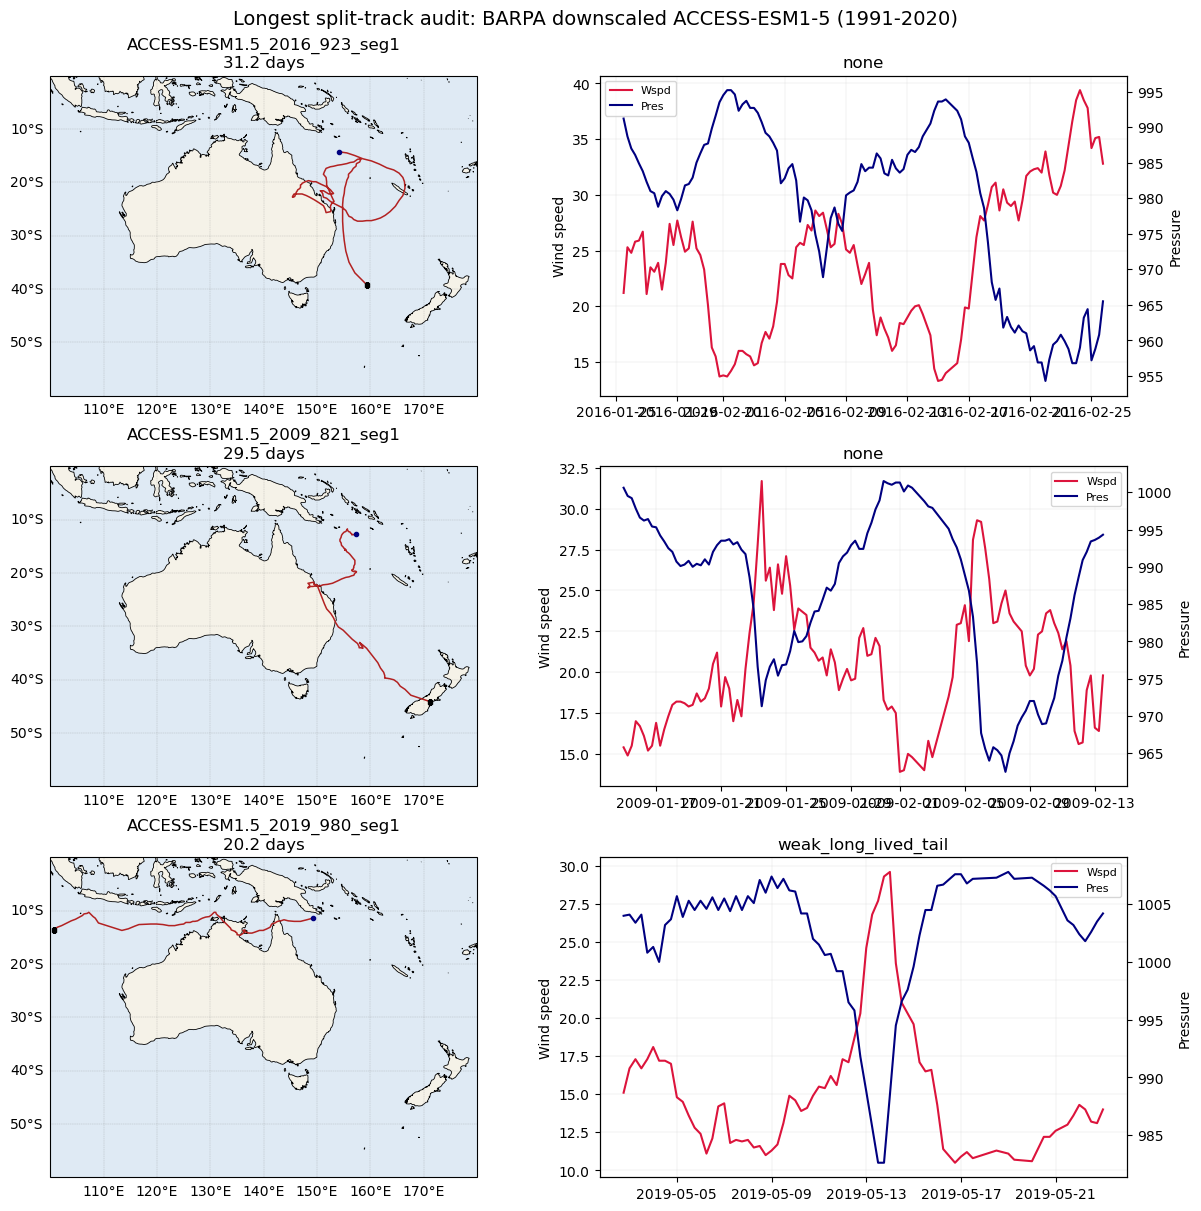

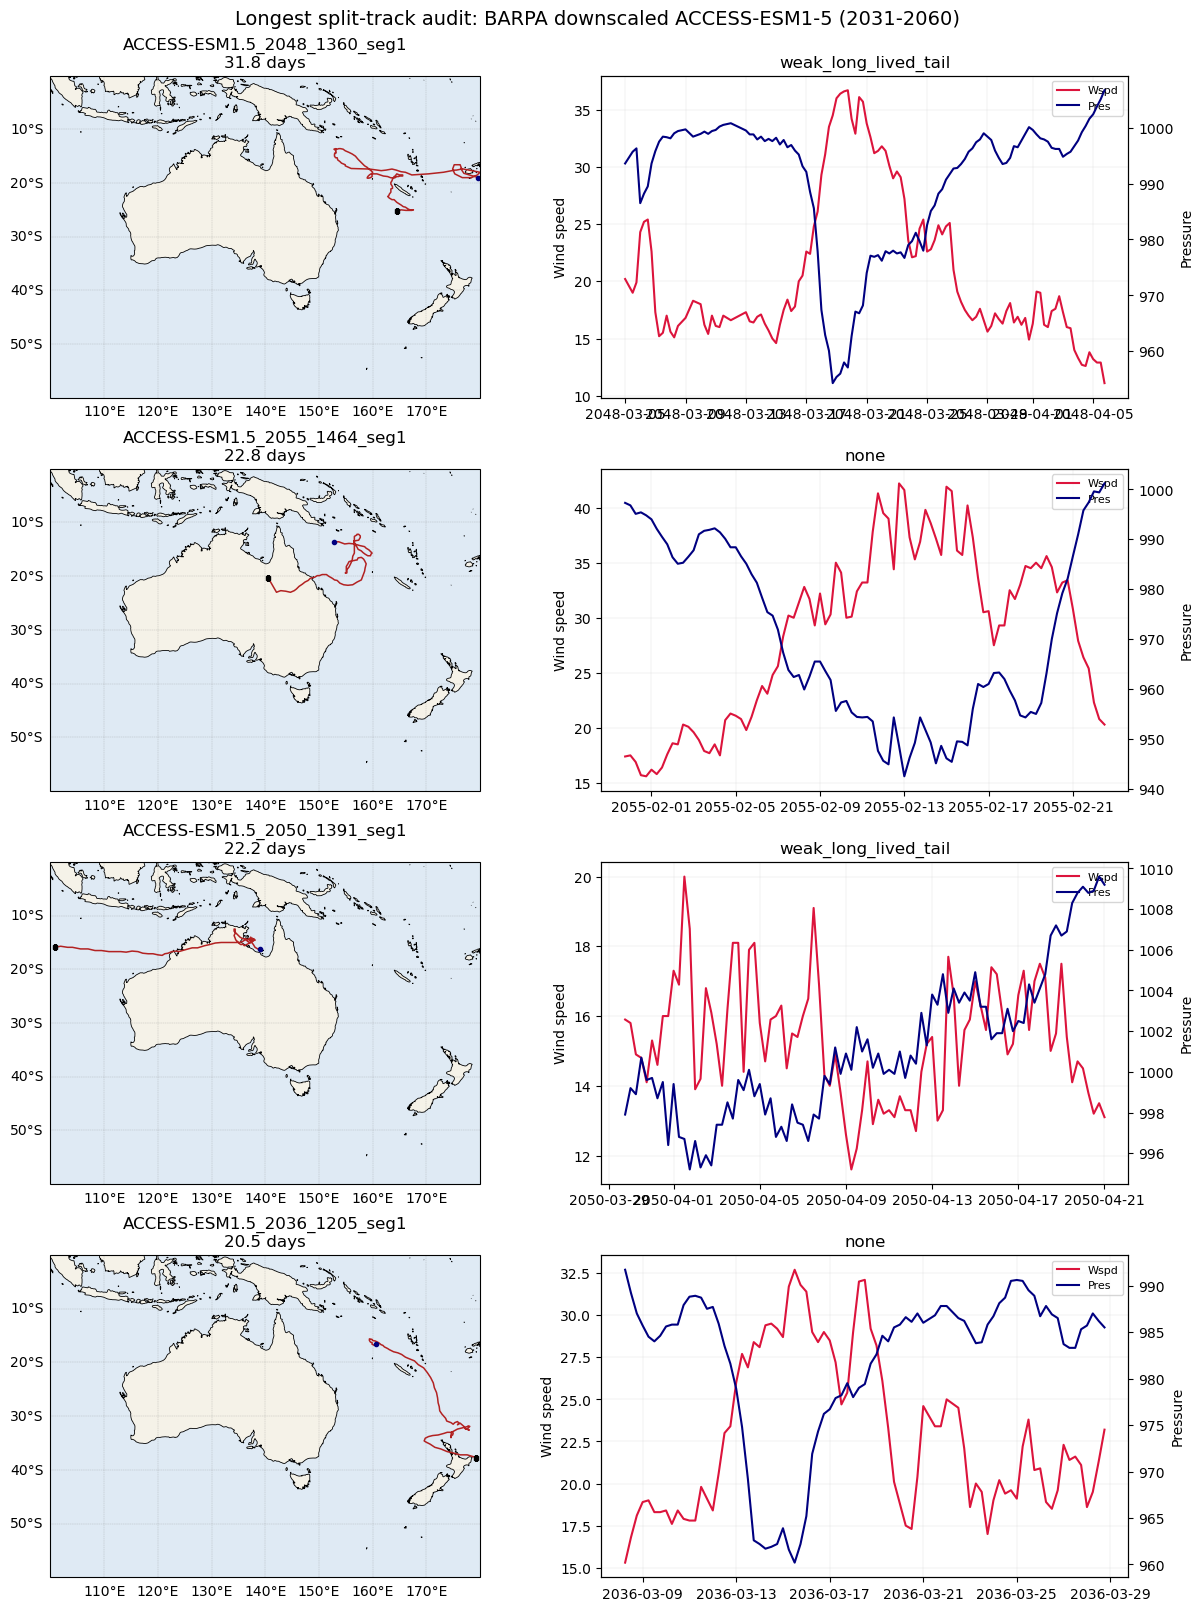

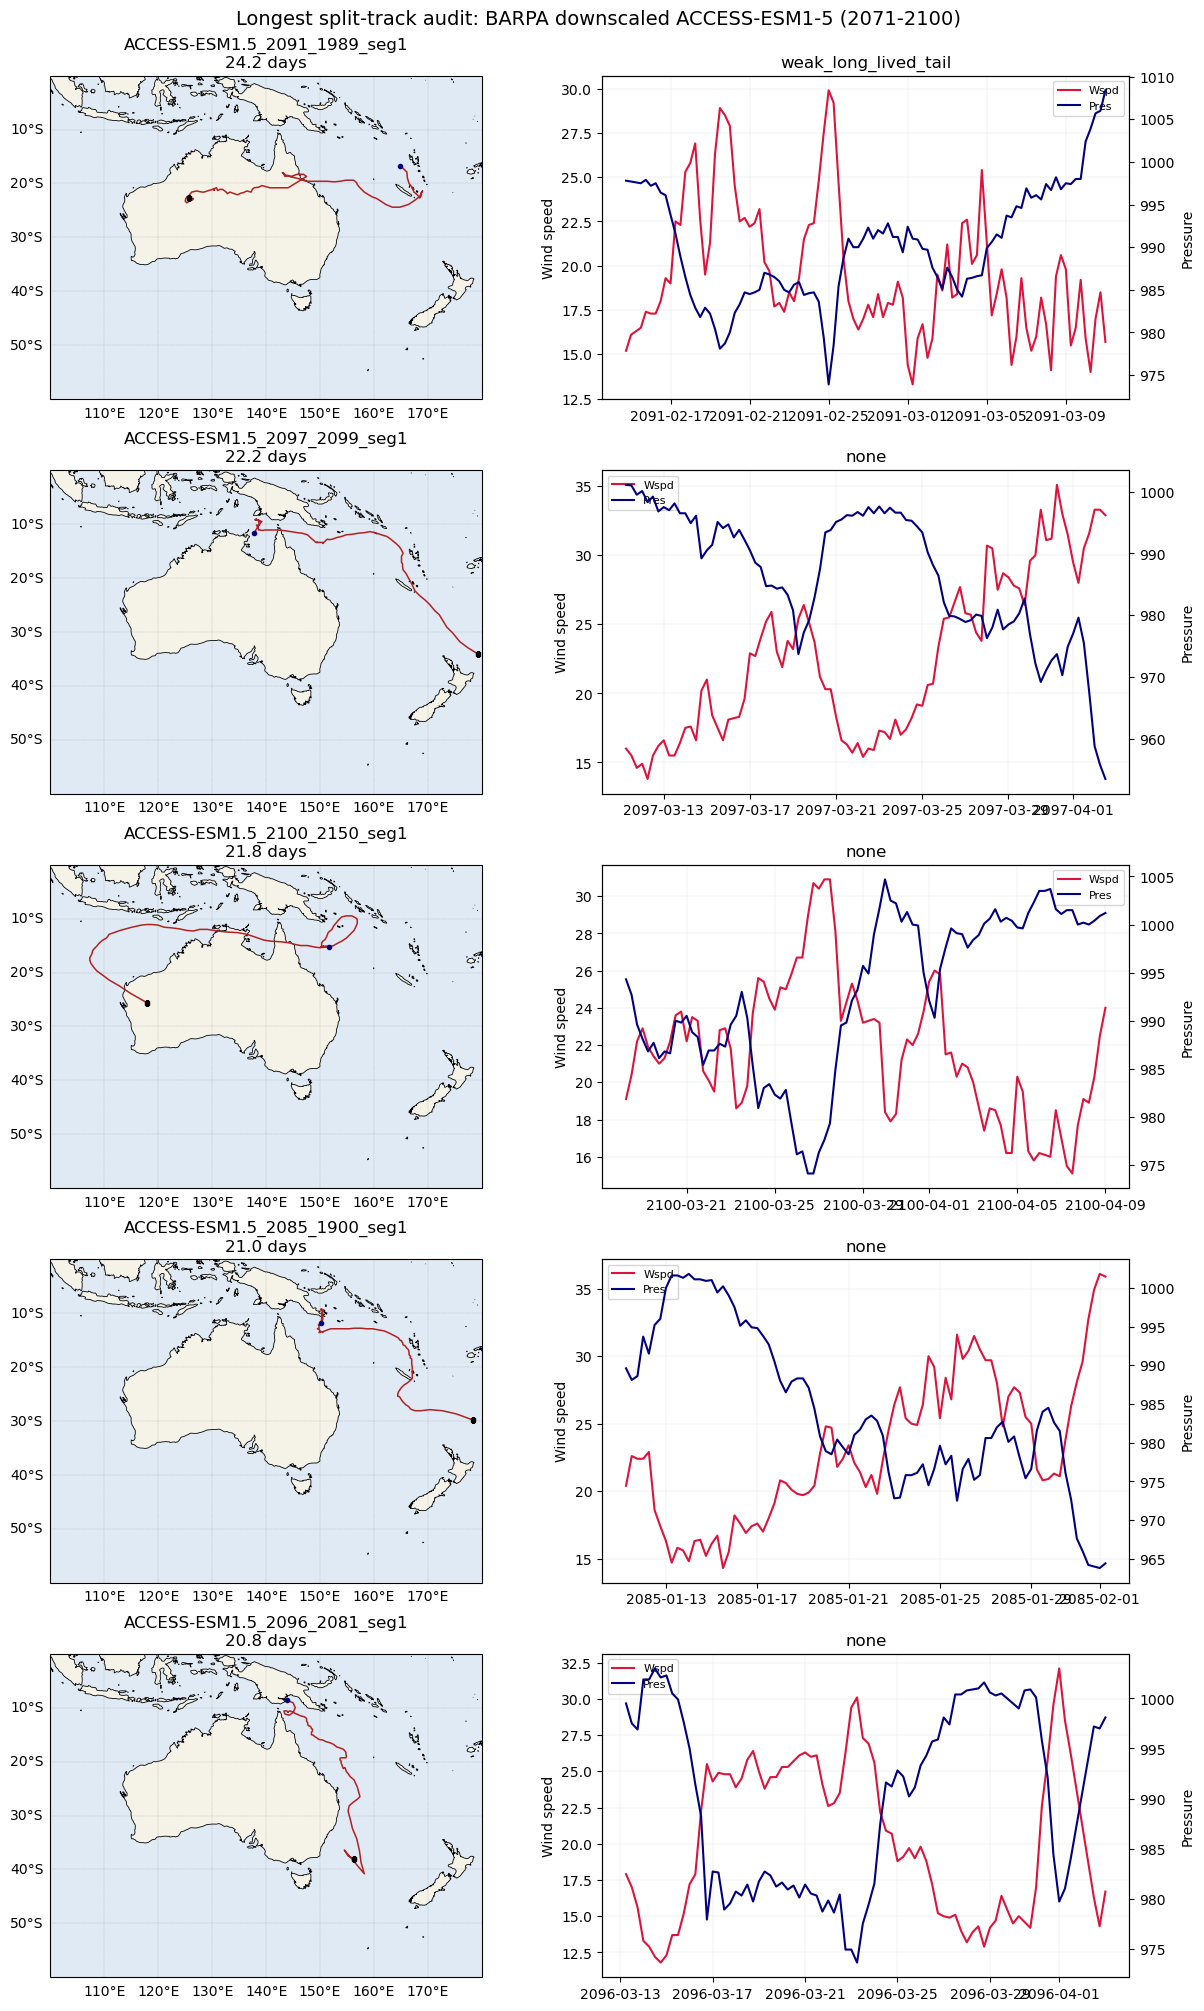

In [ ]:
for spec, period_name, selected_tracks in audit_plot_payload:
    if not selected_tracks:
        continue
    nrows = len(selected_tracks)
    fig = plt.figure(figsize=(12, 4 * nrows), constrained_layout=True)
    gs = fig.add_gridspec(nrows, 2)
    for row_idx, (track_df, meta) in enumerate(selected_tracks):
        ax_map = fig.add_subplot(gs[row_idx, 0], projection=ccrs.PlateCarree())
        ax_ts = fig.add_subplot(gs[row_idx, 1])
        plot_audit_track_row(ax_map, ax_ts, track_df, meta)
    fig.suptitle(f"Longest split-track audit: {spec['label']} ({period_name})", fontsize=14)
    safe_model = spec["model"].replace(".", "_")
    safe_period = period_name.replace("-", "_").replace(" ", "_")
    fig.savefig(OUTPUT_DIR / f"longest_split_tracks_audit_{safe_model}_{safe_period}.png", dpi=300)
    plt.show()

In [ ]:
if not audit_df.empty:
    audit_df.to_csv(OUTPUT_DIR / "ccam_cdd_split_tracks_audit.csv", index=False)
print("Saved split-track audit outputs to", OUTPUT_DIR)

Saved split-track audit outputs to C:\Users\z3519988\OneDrive - UNSW\Files\study\project\csiro\ccam_cdd_outputs


## Longevity change summary
A clearer end summary for seeing track-number decrease and longevity increase across periods.

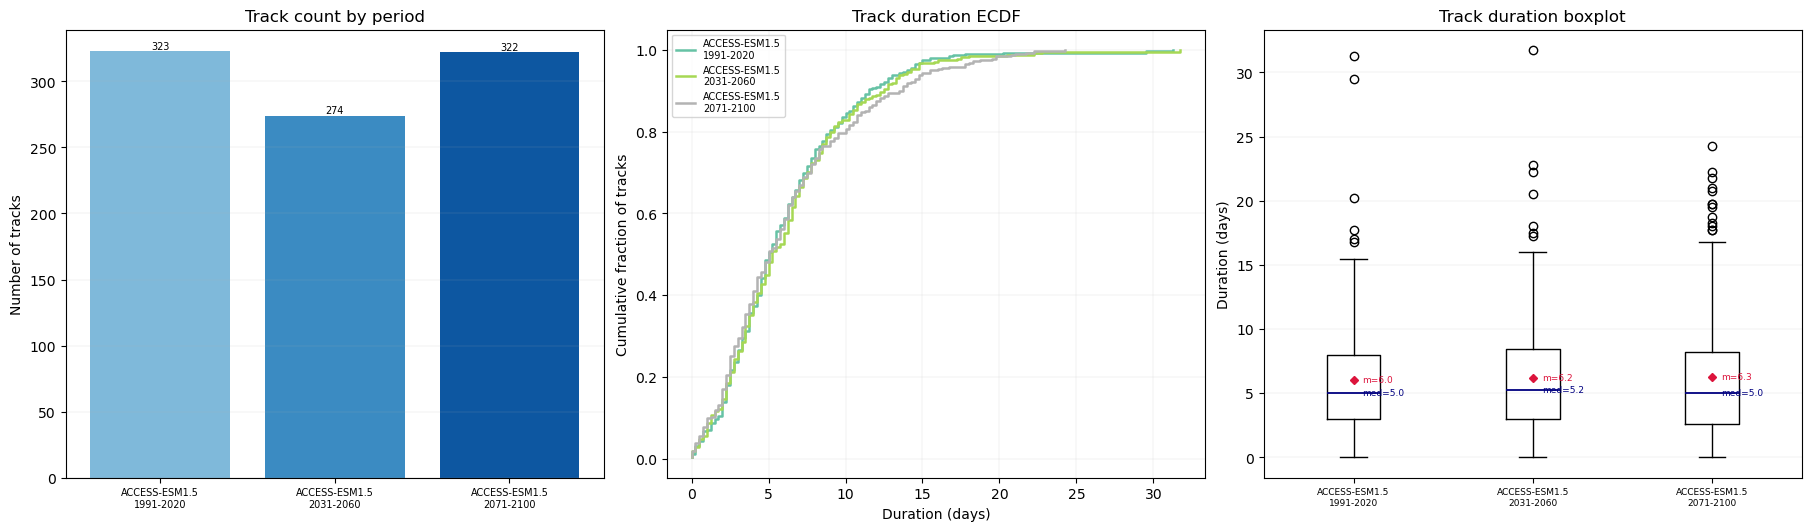

,model,period,n_tracks,mean_days,median_days,p90_days,long_lived_ge_5_days,long_lived_ge_7_days,pct_ge_5_days,pct_ge_7_days
0,ACCESS-ESM1.5,1991-2020,323,6.035604,5.00,11.500,166,111,51.393189,34.365325
1,ACCESS-ESM1.5,2031-2060,274,6.212591,5.25,12.425,151,98,55.109489,35.766423
2,ACCESS-ESM1.5,2071-2100,322,6.256211,5.00,13.500,167,111,51.863354,34.472050


In [ ]:
summary_plot_df = longevity_summary_df.copy()
summary_plot_df = summary_plot_df[summary_plot_df["period"] != "no overlap"].copy()
summary_plot_df["period_sort"] = summary_plot_df["period"].str.split("-").str[0].astype(int)
summary_plot_df = summary_plot_df.sort_values(["model", "period_sort"]).reset_index(drop=True)

plot_items = []
for spec, longevity_df, period_name in longevity_frames:
    if longevity_df.empty or period_name == "no overlap":
        continue
    plot_items.append({
        "spec": spec,
        "period_name": period_name,
        "label": f"{spec['model']}\n{period_name}",
        "durations": longevity_df["duration_days"].to_numpy(),
    })

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), constrained_layout=True)

if not summary_plot_df.empty:
    bar_labels = [f"{row.model}\n{row.period}" for row in summary_plot_df.itertuples()]
    bar_values = summary_plot_df["n_tracks"].to_numpy()
    bars = axes[0].bar(range(len(bar_values)), bar_values, color=plt.cm.Blues(np.linspace(0.45, 0.85, len(bar_values))))
    axes[0].set_xticks(range(len(bar_values)))
    axes[0].set_xticklabels(bar_labels, fontsize=7)
    axes[0].set_ylabel("Number of tracks")
    axes[0].set_title("Track count by period")
    axes[0].grid(True, axis="y", linewidth=0.3, alpha=0.4)
    for bar, value in zip(bars, bar_values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, value, f"{int(value)}", ha="center", va="bottom", fontsize=7)

for item, color in zip(plot_items, plt.cm.Set2(np.linspace(0, 1, max(len(plot_items), 1)))):
    durations = np.sort(item["durations"])
    if durations.size == 0:
        continue
    ecdf = np.arange(1, durations.size + 1) / durations.size
    axes[1].step(durations, ecdf, where="post", label=item["label"], linewidth=1.8, color=color)

axes[1].set_title("Track duration ECDF")
axes[1].set_xlabel("Duration (days)")
axes[1].set_ylabel("Cumulative fraction of tracks")
axes[1].grid(True, linewidth=0.3, alpha=0.4)
axes[1].legend(fontsize=7)

boxplot_data = [item["durations"] for item in plot_items if item["durations"].size > 0]
boxplot_labels = [item["label"] for item in plot_items if item["durations"].size > 0]
if boxplot_data:
    axes[2].boxplot(
        boxplot_data,
        tick_labels=boxplot_labels,
        vert=True,
        showmeans=True,
        meanprops={"marker": "D", "markerfacecolor": "crimson", "markeredgecolor": "crimson", "markersize": 4},
        medianprops={"color": "navy", "linewidth": 1.3},
    )
    for idx, durations in enumerate(boxplot_data, start=1):
        mean_days = float(np.mean(durations))
        median_days = float(np.median(durations))
        axes[2].text(idx + 0.05, mean_days, f"m={mean_days:.1f}", color="crimson", fontsize=6.5, va="center")
        axes[2].text(idx + 0.05, median_days, f"med={median_days:.1f}", color="navy", fontsize=6.5, va="center")

axes[2].set_title("Track duration boxplot")
axes[2].set_ylabel("Duration (days)")
axes[2].tick_params(axis="x", labelrotation=0, labelsize=6.5)
axes[2].grid(True, axis="y", linewidth=0.3, alpha=0.4)

fig.savefig(OUTPUT_DIR / "ccam_cdd_split_tracks_longevity_change_summary.png", dpi=300)
plt.show()

summary_change_table = summary_plot_df[["model", "period", "n_tracks", "mean_days", "median_days", "p90_days", "long_lived_ge_5_days", "long_lived_ge_7_days"]].copy()
if not summary_change_table.empty:
    summary_change_table["pct_ge_5_days"] = 100.0 * summary_change_table["long_lived_ge_5_days"] / summary_change_table["n_tracks"]
    summary_change_table["pct_ge_7_days"] = 100.0 * summary_change_table["long_lived_ge_7_days"] / summary_change_table["n_tracks"]

summary_change_table.to_csv(OUTPUT_DIR / "ccam_cdd_split_tracks_longevity_change_summary.csv", index=False)
summary_change_table



## Across-model evaluation
Compare track count and longevity changes across all models relative to the historical period.

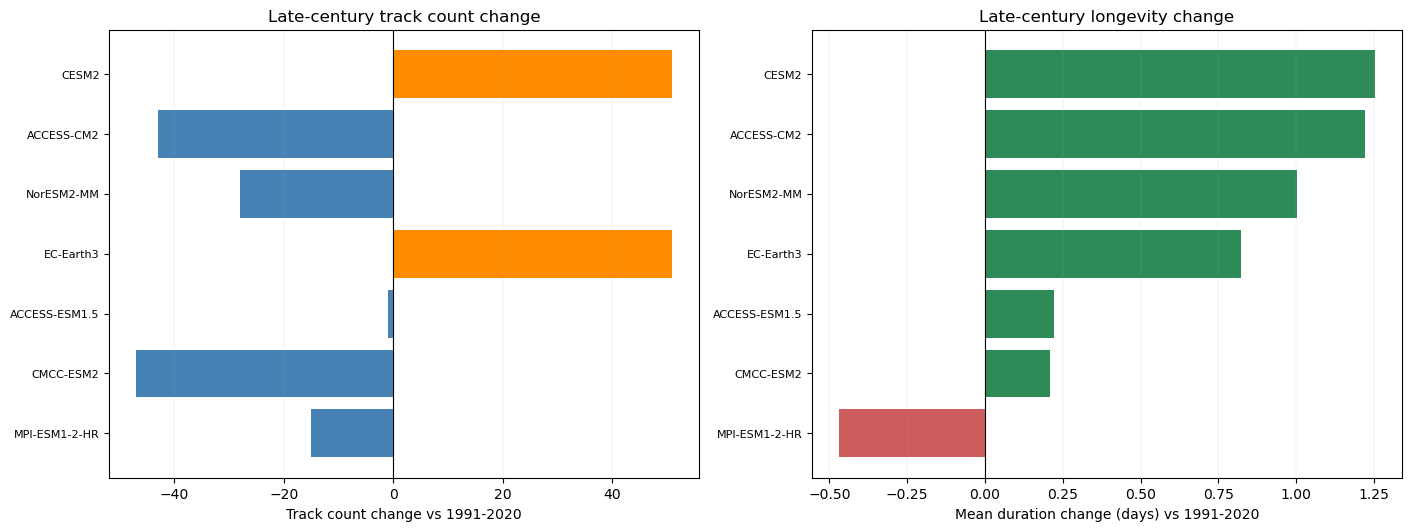

,model,period,n_tracks,track_count_change,mean_days,mean_days_change,median_days,median_days_change,p90_days,p90_days_change,count_signal,longevity_signal
0,ACCESS-CM2,1991-2020,458,0,5.923035,0.000000,4.750,0.000,12.250,0.000,similar count,similar
1,ACCESS-CM2,2031-2060,448,-10,6.132812,0.209778,5.000,0.250,12.075,-0.175,similar count,similar
2,ACCESS-CM2,2071-2100,415,-43,7.143976,1.220941,5.750,1.000,14.400,2.150,fewer tracks,longer
3,ACCESS-ESM1.5,1991-2020,323,0,6.035604,0.000000,5.000,0.000,11.500,0.000,similar count,similar
4,ACCESS-ESM1.5,2031-2060,274,-49,6.212591,0.176988,5.250,0.250,12.425,0.925,fewer tracks,similar
5,ACCESS-ESM1.5,2071-2100,322,-1,6.256211,0.220607,5.000,0.000,13.500,2.000,similar count,similar
6,CESM2,1991-2020,454,0,5.801762,0.000000,4.250,0.000,12.250,0.000,similar count,similar
7,CESM2,2031-2060,512,58,6.542480,0.740718,5.000,0.750,13.725,1.475,more tracks,longer
8,CESM2,2071-2100,505,51,7.054950,1.253188,5.750,1.500,15.000,2.750,more tracks,longer
9,CMCC-ESM2,1991-2020,533,0,5.603189,0.000000,4.250,0.000,11.250,0.000,similar count,similar


In [ ]:
all_models = [
    "ACCESS-CM2",
    "ACCESS-ESM1.5",
    "CMCC-ESM2",
    "EC-Earth3",
    "MPI-ESM1-2-HR",
    "CESM2",
    "NorESM2-MM",
]

comparison_period_choices = ["historical_1991_2020", "future_2031_2060", "future_2071_2100"]
comparison_periods = [resolve_period(choice, None) for choice in comparison_period_choices]

across_rows = []
for model in all_models:
    for period in comparison_periods:
        start_season, end_season = period
        model_df = filter_period(df, model, start_season, end_season)
        period_name = f"{start_season}-{end_season}"
        longevity_df = build_track_longevity(model_df, MODEL_NAME_MAP.get(model, model), period_name)
        summary = summarize_longevity(longevity_df)
        summary.update({
            "model": model,
            "label": MODEL_NAME_MAP.get(model, model),
            "period": period_name,
        })
        across_rows.append(summary)

across_models_df = pd.DataFrame(across_rows)
base_df = across_models_df[across_models_df["period"] == "1991-2020"][["model", "n_tracks", "mean_days", "median_days", "p90_days"]].rename(columns={
    "n_tracks": "hist_n_tracks",
    "mean_days": "hist_mean_days",
    "median_days": "hist_median_days",
    "p90_days": "hist_p90_days",
})
across_eval_df = across_models_df.merge(base_df, on="model", how="left")
across_eval_df["track_count_change"] = across_eval_df["n_tracks"] - across_eval_df["hist_n_tracks"]
across_eval_df["mean_days_change"] = across_eval_df["mean_days"] - across_eval_df["hist_mean_days"]
across_eval_df["median_days_change"] = across_eval_df["median_days"] - across_eval_df["hist_median_days"]
across_eval_df["p90_days_change"] = across_eval_df["p90_days"] - across_eval_df["hist_p90_days"]
across_eval_df["longevity_signal"] = np.select(
    [
        across_eval_df["mean_days_change"] > 0.3,
        across_eval_df["mean_days_change"] < -0.3,
    ],
    ["longer", "shorter"],
    default="similar",
)
across_eval_df["count_signal"] = np.select(
    [
        across_eval_df["track_count_change"] > 20,
        across_eval_df["track_count_change"] < -20,
    ],
    ["more tracks", "fewer tracks"],
    default="similar count",
)

late_century_eval = across_eval_df[across_eval_df["period"] == "2071-2100"].copy()
late_century_eval = late_century_eval.sort_values(["mean_days_change", "track_count_change"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
plot_df = late_century_eval.copy()
ypos = np.arange(len(plot_df))

axes[0].barh(ypos, plot_df["track_count_change"], color=np.where(plot_df["track_count_change"] < 0, "steelblue", "darkorange"))
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(plot_df["model"], fontsize=8)
axes[0].set_xlabel("Track count change vs 1991-2020")
axes[0].set_title("Late-century track count change")
axes[0].grid(True, axis="x", linewidth=0.3, alpha=0.4)

axes[1].barh(ypos, plot_df["mean_days_change"], color=np.where(plot_df["mean_days_change"] < 0, "indianred", "seagreen"))
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_yticks(ypos)
axes[1].set_yticklabels(plot_df["model"], fontsize=8)
axes[1].set_xlabel("Mean duration change (days) vs 1991-2020")
axes[1].set_title("Late-century longevity change")
axes[1].grid(True, axis="x", linewidth=0.3, alpha=0.4)

fig.savefig(OUTPUT_DIR / "ccam_cdd_split_tracks_across_models_late_century.png", dpi=300)
plt.show()

summary_cols = [
    "model", "period", "n_tracks", "track_count_change", "mean_days", "mean_days_change",
    "median_days", "median_days_change", "p90_days", "p90_days_change", "count_signal", "longevity_signal"
]
across_eval_summary = across_eval_df[summary_cols].sort_values(["model", "period"]).reset_index(drop=True)
across_eval_summary.to_csv(OUTPUT_DIR / "ccam_cdd_split_tracks_across_models_evaluation.csv", index=False)
across_eval_summary



## Why longevity changes?
Compare longevity and intensity together to see whether longer-lived periods also look stronger.

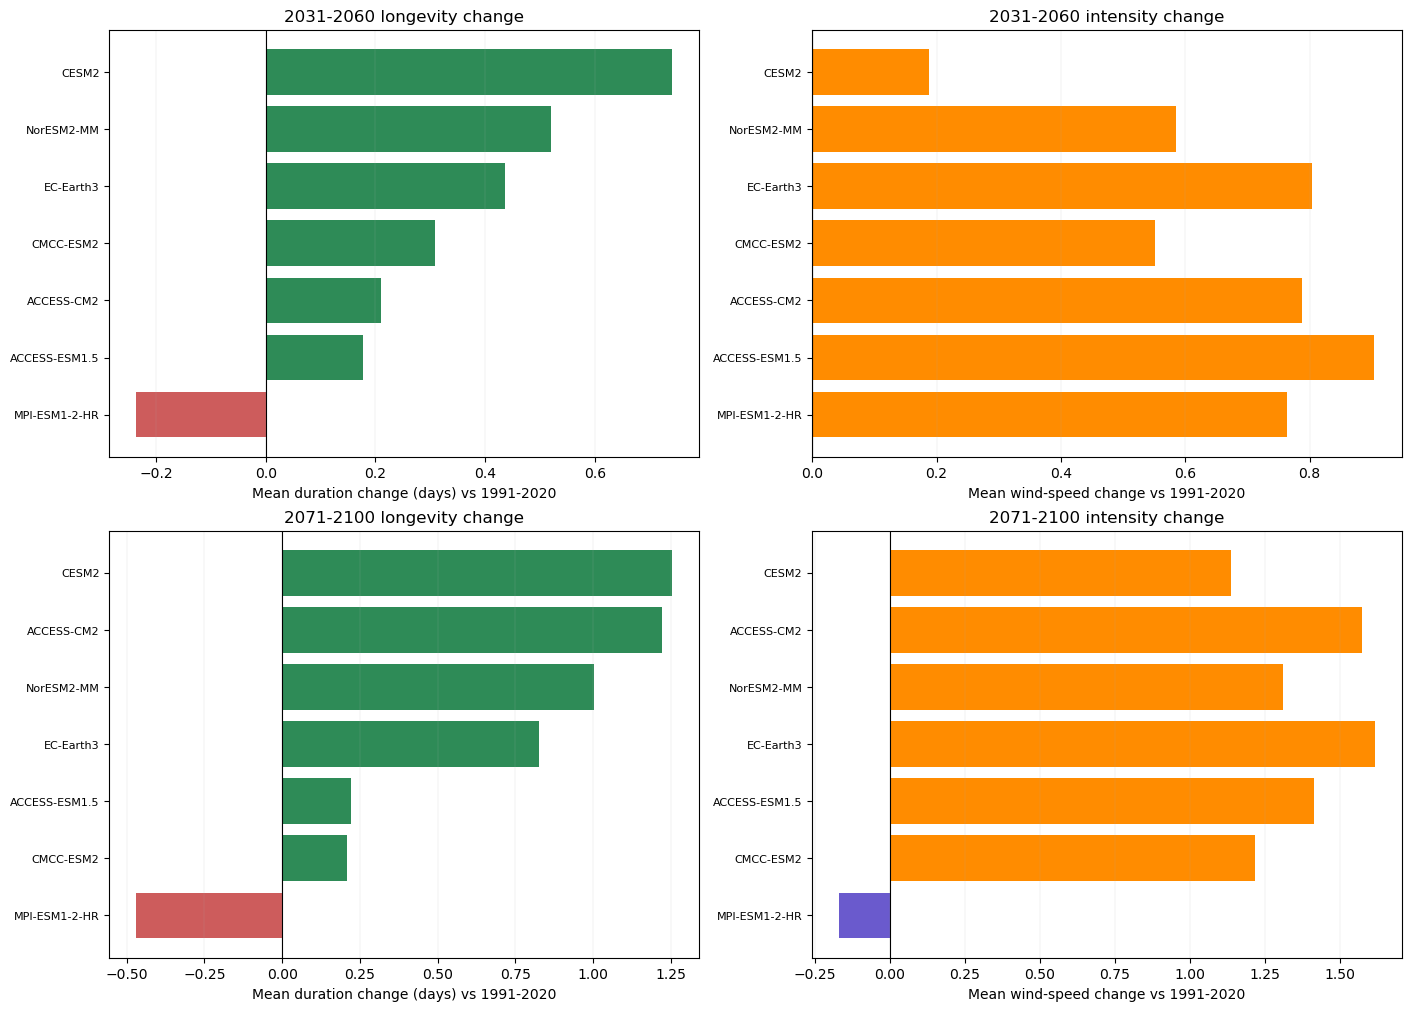

,model,period,n_tracks,mean_days,mean_days_change,mean_wspd_all,mean_wspd_change_all,max_wspd_all,max_wspd_change_all,mean_pres_all,...,min_pres_all,min_pres_change_all,n_long_tracks_ge_7d,mean_wspd_long_ge_7d,mean_wspd_change_long_ge_7d,min_pres_long_ge_7d,min_pres_change_long_ge_7d,longevity_hint,intensity_hint,interpretation
0,ACCESS-CM2,1991-2020,458,5.923035,0.000000,20.957997,0.000000,46.3,0.0,989.145611,...,925.5,0.0,146,21.451344,0.000000,925.5,0.0,similar longevity,similar intensity,small change or mixed signal
1,ACCESS-CM2,2031-2060,448,6.132812,0.209778,21.746253,0.788256,48.2,1.9,987.934732,...,912.8,-12.7,156,22.689484,1.238140,912.8,-12.7,similar longevity,stronger,small change or mixed signal
2,ACCESS-CM2,2071-2100,415,7.143976,1.220941,22.532143,1.574146,50.3,4.0,987.065708,...,922.3,-3.2,167,23.410313,1.958970,922.3,-3.2,longer,stronger,longer and stronger: intensity may contribute
3,ACCESS-ESM1.5,1991-2020,323,6.035604,0.000000,20.698484,0.000000,46.5,0.0,990.197122,...,941.4,0.0,111,20.896442,0.000000,941.4,0.0,similar longevity,similar intensity,small change or mixed signal
4,ACCESS-ESM1.5,2031-2060,274,6.212591,0.176988,21.601429,0.902945,48.4,1.9,988.755120,...,935.8,-5.6,98,22.139378,1.242937,937.1,-4.3,similar longevity,stronger,small change or mixed signal
5,ACCESS-ESM1.5,2071-2100,322,6.256211,0.220607,22.112154,1.413670,44.3,-2.2,988.431557,...,927.6,-13.8,111,23.266948,2.370506,927.6,-13.8,similar longevity,stronger,small change or mixed signal
6,CESM2,1991-2020,454,5.801762,0.000000,22.790003,0.000000,46.6,0.0,982.029377,...,926.3,0.0,157,23.532915,0.000000,926.3,0.0,similar longevity,similar intensity,small change or mixed signal
7,CESM2,2031-2060,512,6.542480,0.740718,22.977358,0.187355,53.7,7.1,982.707481,...,900.6,-25.7,184,23.863218,0.330303,900.6,-25.7,longer,stronger,longer and stronger: intensity may contribute
8,CESM2,2071-2100,505,7.054950,1.253188,23.926263,1.136260,53.3,6.7,982.124379,...,919.4,-6.9,212,24.869429,1.336514,919.4,-6.9,longer,stronger,longer and stronger: intensity may contribute
9,CMCC-ESM2,1991-2020,533,5.603189,0.000000,22.010236,0.000000,47.1,0.0,983.713519,...,928.9,0.0,168,22.954430,0.000000,928.9,0.0,similar longevity,similar intensity,small change or mixed signal


In [ ]:
all_models = [
    "ACCESS-CM2",
    "ACCESS-ESM1.5",
    "CMCC-ESM2",
    "EC-Earth3",
    "MPI-ESM1-2-HR",
    "CESM2",
    "NorESM2-MM",
]
comparison_periods = [(1991, 2020), (2031, 2060), (2071, 2100)]

reason_rows = []
for model in all_models:
    for start_season, end_season in comparison_periods:
        period_name = f"{start_season}-{end_season}"
        period_df = filter_period(df, model, start_season, end_season)
        if period_df.empty:
            continue
        longevity_df = build_track_longevity(period_df, MODEL_NAME_MAP.get(model, model), period_name)
        if longevity_df.empty:
            continue
        long_mask = longevity_df["duration_days"] >= 7.0
        long_track_keys = set(longevity_df.loc[long_mask, "TrackKey"].tolist())
        long_track_df = period_df[period_df["TrackKey"].isin(long_track_keys)].copy()
        reason_rows.append({
            "model": model,
            "period": period_name,
            "n_tracks": int(longevity_df.shape[0]),
            "mean_days": float(longevity_df["duration_days"].mean()),
            "median_days": float(longevity_df["duration_days"].median()),
            "mean_wspd_all": float(period_df["Wspd"].mean()),
            "max_wspd_all": float(period_df["Wspd"].max()),
            "mean_pres_all": float(period_df["Pres"].mean()),
            "min_pres_all": float(period_df["Pres"].min()),
            "n_long_tracks_ge_7d": int(long_mask.sum()),
            "mean_wspd_long_ge_7d": float(long_track_df["Wspd"].mean()) if not long_track_df.empty else np.nan,
            "max_wspd_long_ge_7d": float(long_track_df["Wspd"].max()) if not long_track_df.empty else np.nan,
            "mean_pres_long_ge_7d": float(long_track_df["Pres"].mean()) if not long_track_df.empty else np.nan,
            "min_pres_long_ge_7d": float(long_track_df["Pres"].min()) if not long_track_df.empty else np.nan,
        })

reason_df = pd.DataFrame(reason_rows)
base_cols = [
    "model", "mean_days", "mean_wspd_all", "max_wspd_all", "mean_pres_all", "min_pres_all",
    "mean_wspd_long_ge_7d", "max_wspd_long_ge_7d", "mean_pres_long_ge_7d", "min_pres_long_ge_7d"
]
base_reason = reason_df[reason_df["period"] == "1991-2020"][base_cols].rename(columns={
    "mean_days": "hist_mean_days",
    "mean_wspd_all": "hist_mean_wspd_all",
    "max_wspd_all": "hist_max_wspd_all",
    "mean_pres_all": "hist_mean_pres_all",
    "min_pres_all": "hist_min_pres_all",
    "mean_wspd_long_ge_7d": "hist_mean_wspd_long_ge_7d",
    "max_wspd_long_ge_7d": "hist_max_wspd_long_ge_7d",
    "mean_pres_long_ge_7d": "hist_mean_pres_long_ge_7d",
    "min_pres_long_ge_7d": "hist_min_pres_long_ge_7d",
})

reason_eval = reason_df.merge(base_reason, on="model", how="left")
reason_eval["mean_days_change"] = reason_eval["mean_days"] - reason_eval["hist_mean_days"]
reason_eval["mean_wspd_change_all"] = reason_eval["mean_wspd_all"] - reason_eval["hist_mean_wspd_all"]
reason_eval["max_wspd_change_all"] = reason_eval["max_wspd_all"] - reason_eval["hist_max_wspd_all"]
reason_eval["mean_pres_change_all"] = reason_eval["mean_pres_all"] - reason_eval["hist_mean_pres_all"]
reason_eval["min_pres_change_all"] = reason_eval["min_pres_all"] - reason_eval["hist_min_pres_all"]
reason_eval["mean_wspd_change_long_ge_7d"] = reason_eval["mean_wspd_long_ge_7d"] - reason_eval["hist_mean_wspd_long_ge_7d"]
reason_eval["min_pres_change_long_ge_7d"] = reason_eval["min_pres_long_ge_7d"] - reason_eval["hist_min_pres_long_ge_7d"]

reason_eval["intensity_hint"] = np.select(
    [
        (reason_eval["mean_wspd_change_all"] > 0.5) | (reason_eval["min_pres_change_all"] < -1.0),
        (reason_eval["mean_wspd_change_all"] < -0.5) | (reason_eval["min_pres_change_all"] > 1.0),
    ],
    ["stronger", "weaker"],
    default="similar intensity",
)
reason_eval["longevity_hint"] = np.select(
    [
        reason_eval["mean_days_change"] > 0.3,
        reason_eval["mean_days_change"] < -0.3,
    ],
    ["longer", "shorter"],
    default="similar longevity",
)
reason_eval["interpretation"] = np.select(
    [
        (reason_eval["longevity_hint"] == "longer") & (reason_eval["intensity_hint"] == "stronger"),
        (reason_eval["longevity_hint"] == "longer") & (reason_eval["intensity_hint"] != "stronger"),
        (reason_eval["longevity_hint"] == "shorter") & (reason_eval["intensity_hint"] == "weaker"),
        (reason_eval["longevity_hint"] == "shorter") & (reason_eval["intensity_hint"] != "weaker"),
    ],
    [
        "longer and stronger: intensity may contribute",
        "longer without clear strengthening: environment/track changes may matter more",
        "shorter and weaker: weaker storms may contribute",
        "shorter without clear weakening: track/environment changes may matter more",
    ],
    default="small change or mixed signal",
)

plot_periods = ["2031-2060", "2071-2100"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for row_idx, period_name in enumerate(plot_periods):
    period_plot = reason_eval[reason_eval["period"] == period_name].copy().sort_values("mean_days_change")
    ypos = np.arange(len(period_plot))

    axes[row_idx, 0].barh(ypos, period_plot["mean_days_change"], color=np.where(period_plot["mean_days_change"] < 0, "indianred", "seagreen"))
    axes[row_idx, 0].axvline(0, color="black", linewidth=0.8)
    axes[row_idx, 0].set_yticks(ypos)
    axes[row_idx, 0].set_yticklabels(period_plot["model"], fontsize=8)
    axes[row_idx, 0].set_xlabel("Mean duration change (days) vs 1991-2020")
    axes[row_idx, 0].set_title(f"{period_name} longevity change")
    axes[row_idx, 0].grid(True, axis="x", linewidth=0.3, alpha=0.4)

    axes[row_idx, 1].barh(ypos, period_plot["mean_wspd_change_all"], color=np.where(period_plot["mean_wspd_change_all"] < 0, "slateblue", "darkorange"))
    axes[row_idx, 1].axvline(0, color="black", linewidth=0.8)
    axes[row_idx, 1].set_yticks(ypos)
    axes[row_idx, 1].set_yticklabels(period_plot["model"], fontsize=8)
    axes[row_idx, 1].set_xlabel("Mean wind-speed change vs 1991-2020")
    axes[row_idx, 1].set_title(f"{period_name} intensity change")
    axes[row_idx, 1].grid(True, axis="x", linewidth=0.3, alpha=0.4)

fig.savefig(OUTPUT_DIR / "ccam_cdd_split_tracks_longevity_reasoning_future_periods.png", dpi=300)
plt.show()

reason_summary_cols = [
    "model", "period", "n_tracks", "mean_days", "mean_days_change", "mean_wspd_all", "mean_wspd_change_all",
    "max_wspd_all", "max_wspd_change_all", "mean_pres_all", "mean_pres_change_all", "min_pres_all", "min_pres_change_all",
    "n_long_tracks_ge_7d", "mean_wspd_long_ge_7d", "mean_wspd_change_long_ge_7d", "min_pres_long_ge_7d", "min_pres_change_long_ge_7d",
    "longevity_hint", "intensity_hint", "interpretation"
]
reason_summary = reason_eval[reason_summary_cols].sort_values(["model", "period"]).reset_index(drop=True)
reason_summary.to_csv(OUTPUT_DIR / "ccam_cdd_split_tracks_longevity_reasoning.csv", index=False)
reason_summary



## ERA5 baseline comparison
Compare all models and periods against the common ERA5 historical baseline (1991-2020) for TC number, longevity, and intensity.

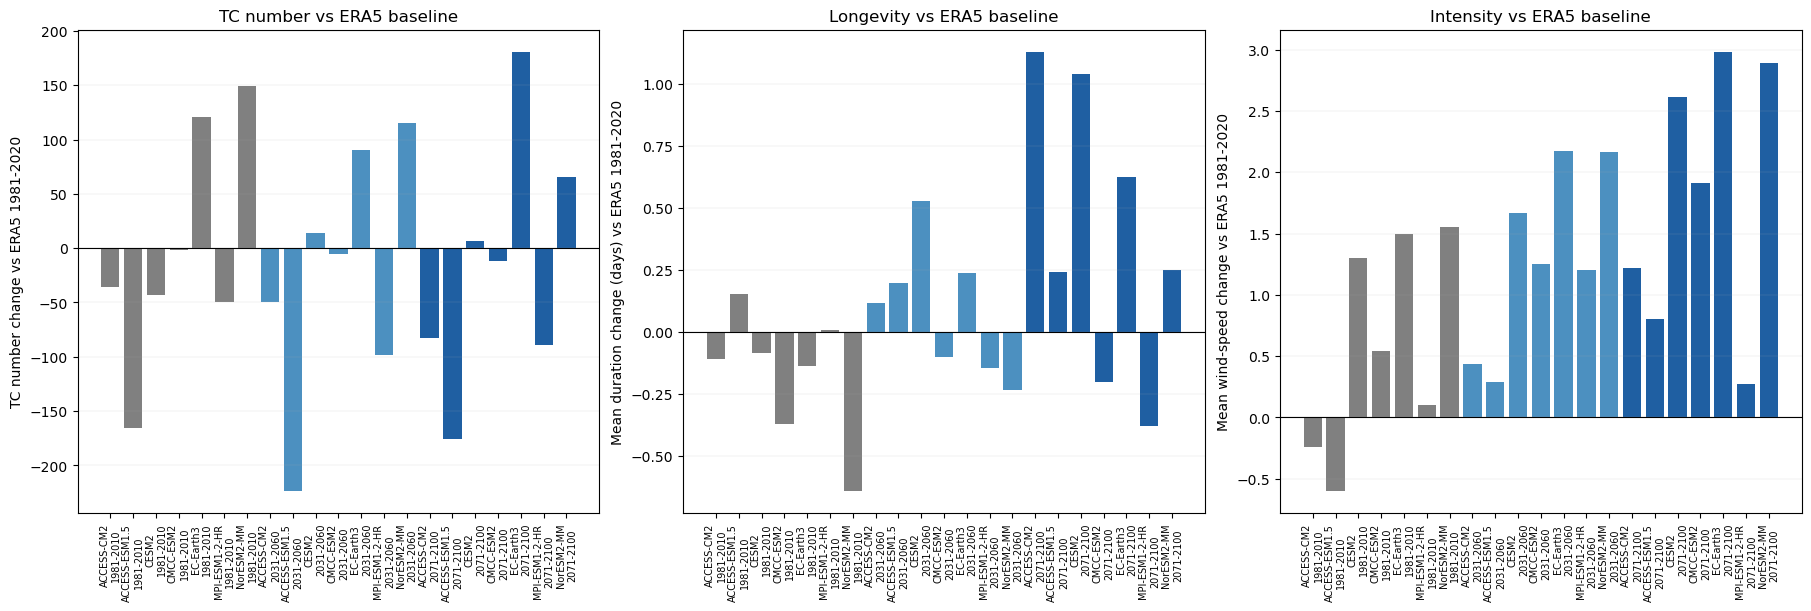

,model,period,n_tracks,track_count_vs_era5,mean_days,mean_days_vs_era5,median_days,median_days_vs_era5,p90_days,mean_wspd,mean_wspd_vs_era5,max_wspd,max_wspd_vs_era5,mean_pres,mean_pres_vs_era5,min_pres,min_pres_vs_era5
0,ACCESS-CM2,1981-2010,462,-36,5.905844,-0.108714,5.000,0.000,11.750,21.066958,-0.242753,42.7,-4.8,988.870980,1.358029,943.7,14.6
1,ACCESS-ESM1.5,1981-2010,332,-166,6.167169,0.152610,5.375,0.375,11.500,20.706183,-0.603529,42.4,-5.1,990.226625,2.713673,941.4,12.3
2,CESM2,1981-2010,455,-43,5.930769,-0.083789,4.250,-0.750,12.250,22.607358,1.297646,48.7,1.2,982.290575,-5.222377,914.8,-14.3
3,CMCC-ESM2,1981-2010,496,-2,5.645665,-0.368893,4.500,-0.500,11.750,21.850493,0.540781,45.5,-2.0,983.922582,-3.590369,929.9,0.8
4,EC-Earth3,1981-2010,619,121,5.878837,-0.135721,5.000,0.000,11.500,22.804847,1.495136,48.9,1.4,982.811678,-4.701273,927.9,-1.2
5,MPI-ESM1-2-HR,1981-2010,448,-50,6.023996,0.009437,5.000,0.000,11.750,21.410851,0.101139,45.1,-2.4,988.043706,0.530755,931.1,2.0
6,NorESM2-MM,1981-2010,647,149,5.372875,-0.641683,4.250,-0.750,10.850,22.860326,1.550614,50.0,2.5,981.443410,-6.069542,923.8,-5.3
7,ERA5,1981-2020,498,0,6.014558,0.000000,5.000,0.000,12.325,21.309712,0.000000,47.5,0.0,987.512952,0.000000,929.1,0.0
8,ACCESS-CM2,2031-2060,448,-50,6.132812,0.118254,5.000,0.000,12.075,21.746253,0.436541,48.2,0.7,987.934732,0.421780,912.8,-16.3
9,ACCESS-ESM1.5,2031-2060,274,-224,6.212591,0.198033,5.250,0.250,12.425,21.601429,0.291718,48.4,0.9,988.755120,1.242168,935.8,6.7


In [ ]:
all_models = [
    "ACCESS-CM2",
    "ACCESS-ESM1.5",
    "CMCC-ESM2",
    "EC-Earth3",
    "MPI-ESM1-2-HR",
    "CESM2",
    "NorESM2-MM",
]

# You can change this ERA5 reference period safely.
ERA5_BASELINE_PERIOD = (1991, 2020)

# These are the model periods to compare against the ERA5 baseline.
MODEL_COMPARISON_PERIODS = [
    (1991, 2020),
    (2031, 2060),
    (2071, 2100),
]

era5_rows = []
era5_start, era5_end = ERA5_BASELINE_PERIOD
era5_period_name = f"{era5_start}-{era5_end}"

# First build the ERA5 baseline row.
era5_df = filter_period(df, "ERA5", era5_start, era5_end)
if era5_df.empty:
    raise ValueError(f"No ERA5 data found for baseline period {era5_period_name}")
era5_longevity_df = build_track_longevity(era5_df, MODEL_NAME_MAP.get("ERA5", "ERA5"), era5_period_name)
if era5_longevity_df.empty:
    raise ValueError(f"No ERA5 tracks found for baseline period {era5_period_name}")
era5_rows.append({
    "model": "ERA5",
    "period": era5_period_name,
    "n_tracks": int(era5_longevity_df.shape[0]),
    "mean_days": float(era5_longevity_df["duration_days"].mean()),
    "median_days": float(era5_longevity_df["duration_days"].median()),
    "p90_days": float(era5_longevity_df["duration_days"].quantile(0.9)),
    "mean_wspd": float(era5_df["Wspd"].mean()),
    "max_wspd": float(era5_df["Wspd"].max()),
    "mean_pres": float(era5_df["Pres"].mean()),
    "min_pres": float(era5_df["Pres"].min()),
})

# Then build rows for all model periods.
for model in all_models:
    for start_season, end_season in MODEL_COMPARISON_PERIODS:
        period_name = f"{start_season}-{end_season}"
        period_df = filter_period(df, model, start_season, end_season)
        if period_df.empty:
            continue
        longevity_df = build_track_longevity(period_df, MODEL_NAME_MAP.get(model, model), period_name)
        if longevity_df.empty:
            continue
        era5_rows.append({
            "model": model,
            "period": period_name,
            "n_tracks": int(longevity_df.shape[0]),
            "mean_days": float(longevity_df["duration_days"].mean()),
            "median_days": float(longevity_df["duration_days"].median()),
            "p90_days": float(longevity_df["duration_days"].quantile(0.9)),
            "mean_wspd": float(period_df["Wspd"].mean()),
            "max_wspd": float(period_df["Wspd"].max()),
            "mean_pres": float(period_df["Pres"].mean()),
            "min_pres": float(period_df["Pres"].min()),
        })

era5_compare_df = pd.DataFrame(era5_rows)
era5_base = era5_compare_df[(era5_compare_df["model"] == "ERA5") & (era5_compare_df["period"] == era5_period_name)].iloc[0].to_dict()

era5_compare_df["track_count_vs_era5"] = era5_compare_df["n_tracks"] - era5_base["n_tracks"]
era5_compare_df["mean_days_vs_era5"] = era5_compare_df["mean_days"] - era5_base["mean_days"]
era5_compare_df["median_days_vs_era5"] = era5_compare_df["median_days"] - era5_base["median_days"]
era5_compare_df["mean_wspd_vs_era5"] = era5_compare_df["mean_wspd"] - era5_base["mean_wspd"]
era5_compare_df["max_wspd_vs_era5"] = era5_compare_df["max_wspd"] - era5_base["max_wspd"]
era5_compare_df["mean_pres_vs_era5"] = era5_compare_df["mean_pres"] - era5_base["mean_pres"]
era5_compare_df["min_pres_vs_era5"] = era5_compare_df["min_pres"] - era5_base["min_pres"]

plot_df = era5_compare_df[era5_compare_df["model"] != "ERA5"].copy()
period_order = ["1991-2020", "2031-2060", "2071-2100"]
model_order = all_models
plot_df["period"] = pd.Categorical(plot_df["period"], categories=period_order, ordered=True)
plot_df["model"] = pd.Categorical(plot_df["model"], categories=model_order, ordered=True)
plot_df = plot_df.sort_values(["model", "period"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
colors = {"1991-2020": "#8fbcd4", "2031-2060": "#4c90c0", "2071-2100": "#1f5fa2"}
bar_width = 0.22
x = np.arange(len(model_order))

metrics = [
    ("track_count_vs_era5", f"TC number change vs ERA5 {era5_period_name}", "TC number vs ERA5 baseline"),
    ("mean_days_vs_era5", f"Mean duration change (days) vs ERA5 {era5_period_name}", "Longevity vs ERA5 baseline"),
    ("mean_wspd_vs_era5", f"Mean wind-speed change vs ERA5 {era5_period_name}", "Intensity vs ERA5 baseline"),
]

for ax, (metric, ylabel, title) in zip(axes, metrics):
    for idx, period in enumerate(period_order):
        period_vals = []
        for model in model_order:
            match = plot_df[(plot_df["model"] == model) & (plot_df["period"] == period)]
            period_vals.append(match[metric].iloc[0] if not match.empty else np.nan)
        ax.bar(x + (idx - 1) * bar_width, period_vals, width=bar_width, color=colors[period], label=period)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", linewidth=0.3, alpha=0.4)

axes[0].legend(title="Period", fontsize=8, title_fontsize=8)

fig.savefig(OUTPUT_DIR / "ccam_cdd_split_tracks_vs_era5_baseline.png", dpi=300)
plt.show()

era5_summary_cols = [
    "model", "period", "n_tracks", "track_count_vs_era5", "mean_days", "mean_days_vs_era5",
    "median_days", "median_days_vs_era5", "p90_days", "mean_wspd", "mean_wspd_vs_era5",
    "max_wspd", "max_wspd_vs_era5", "mean_pres", "mean_pres_vs_era5", "min_pres", "min_pres_vs_era5"
]
era5_summary = era5_compare_df[era5_summary_cols].sort_values(["period", "model"]).reset_index(drop=True)
era5_summary.to_csv(OUTPUT_DIR / "ccam_cdd_split_tracks_vs_era5_baseline.csv", index=False)
era5_summary
